# Stress Prediction with Explainable ML + Counterfactual + GenAI

Notebook end-to-end untuk penelitian UAS S2 Kecerdasan Komputasional.

**Pipeline**: Predict (CatBoost/RF/TabNet) → Explain (SHAP) → Prescribe (DiCE Counterfactual) → Naturalize (GPT-4o-mini).

**Dataset**: `sleep_health_dataset.csv` (100k baris × 32 kolom, sintetis).

**Cara pakai**:
- Toggle `USE_SAMPLE = True` di Section 0 untuk iterasi cepat dengan 10k sampel.
- Pause points: setelah Section 4 (CatBoost milestone), Section 9 (CF), Section 10 (GenAI first run).
- Section 13: re-run full 100k.

---

## Section 0 — Setup & Konfigurasi


In [1]:
import os
import json
import time
import joblib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 100

# === KONFIGURASI ===
RANDOM_STATE = 42
USE_SAMPLE = False            # set False di Section 13 untuk full 100k
SAMPLE_SIZE = 10_000

DATA_PATH = Path('sleep_health_dataset.csv')
PROCESSED_DIR = Path('data/processed')
MODELS_DIR = Path('models')
FIGURES_DIR = Path('outputs/figures')
REPORTS_DIR = Path('outputs/reports')
RECOMMENDATIONS_DIR = Path('outputs/recommendations')

for d in [PROCESSED_DIR, MODELS_DIR, FIGURES_DIR, REPORTS_DIR, RECOMMENDATIONS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# === API KEY (untuk Section 10 saja) ===
load_dotenv()
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

print(f"USE_SAMPLE       : {USE_SAMPLE}")
print(f"Sample size      : {SAMPLE_SIZE if USE_SAMPLE else 'full 100k'}")
print(f"RANDOM_STATE     : {RANDOM_STATE}")
print(f"OpenAI key loaded: {'OK' if OPENAI_API_KEY else 'MISSING (Section 10 akan di-skip)'}")


USE_SAMPLE       : False
Sample size      : full 100k
RANDOM_STATE     : 42
OpenAI key loaded: OK


## Section 1 — Load & Sampling

Stratified sampling 10k berdasarkan desil `stress_score` untuk preserve distribusi target.


In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Full dataset shape: {df_raw.shape}")
print(f"Columns          : {len(df_raw.columns)}")

if USE_SAMPLE:
    bins = pd.qcut(df_raw['stress_score'], q=10, labels=False, duplicates='drop')
    df = (
        df_raw.groupby(bins, group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), SAMPLE_SIZE // 10), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )
else:
    df = df_raw.copy()

print(f"Working dataset  : {df.shape}")
df.head()


Full dataset shape: (100000, 32)
Columns          : 32
Working dataset  : (100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   occupation                   100000 non-null  str    
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  str    
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  alcohol_uni

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.0,25000.75,50000.50,75000.25,100000.0
age,100000.0,34.706870,11.036373,18.0,26.00,33.00,42.00,69.0
bmi,100000.0,26.289673,4.479578,16.0,23.20,26.30,29.30,45.0
sleep_duration_hrs,100000.0,6.423986,1.274627,3.0,5.53,6.36,7.27,10.5
sleep_quality_score,100000.0,4.871144,1.506517,1.0,3.80,4.90,6.00,10.0
rem_percentage,100000.0,20.243968,3.411354,10.0,18.00,20.30,22.60,30.0
deep_sleep_percentage,100000.0,20.253375,4.251096,5.0,17.40,20.30,23.20,30.0
sleep_latency_mins,100000.0,19.836810,7.584343,1.0,14.00,19.00,25.00,58.0
wake_episodes_per_night,100000.0,3.346610,1.920877,0.0,2.00,3.00,5.00,8.0
caffeine_mg_before_bed,100000.0,38.849500,69.395818,0.0,0.00,0.00,80.00,400.0


In [5]:
missing = df.isna().sum().sort_values(ascending=False)
if missing.sum() == 0:
    print("✓ Tidak ada missing value")
else:
    print(f"Missing total: {missing.sum()}")
    print(missing[missing > 0])


✓ Tidak ada missing value


## Section 2 — EDA

Verifikasi statistik draft: mean `stress_score` ≈ 5.73, korelasi `sleep_quality_score` dengan target ≈ -0.639.


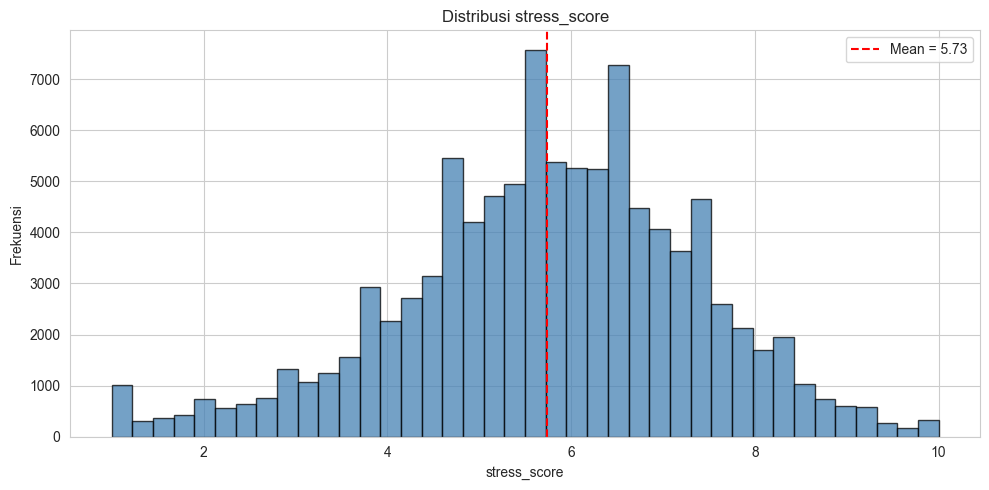

Mean : 5.733  (target draft ≈ 5.73)
Std  : 1.619  (target draft ≈ 1.62)


In [6]:
# 2.1 Distribusi target
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['stress_score'], bins=40, edgecolor='black', alpha=0.75, color='steelblue')
ax.axvline(df['stress_score'].mean(), color='red', linestyle='--',
           label=f"Mean = {df['stress_score'].mean():.2f}")
ax.set_xlabel('stress_score')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi stress_score')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_stress_distribution.png')
plt.show()

print(f"Mean : {df['stress_score'].mean():.3f}  (target draft ≈ 5.73)")
print(f"Std  : {df['stress_score'].std():.3f}  (target draft ≈ 1.62)")


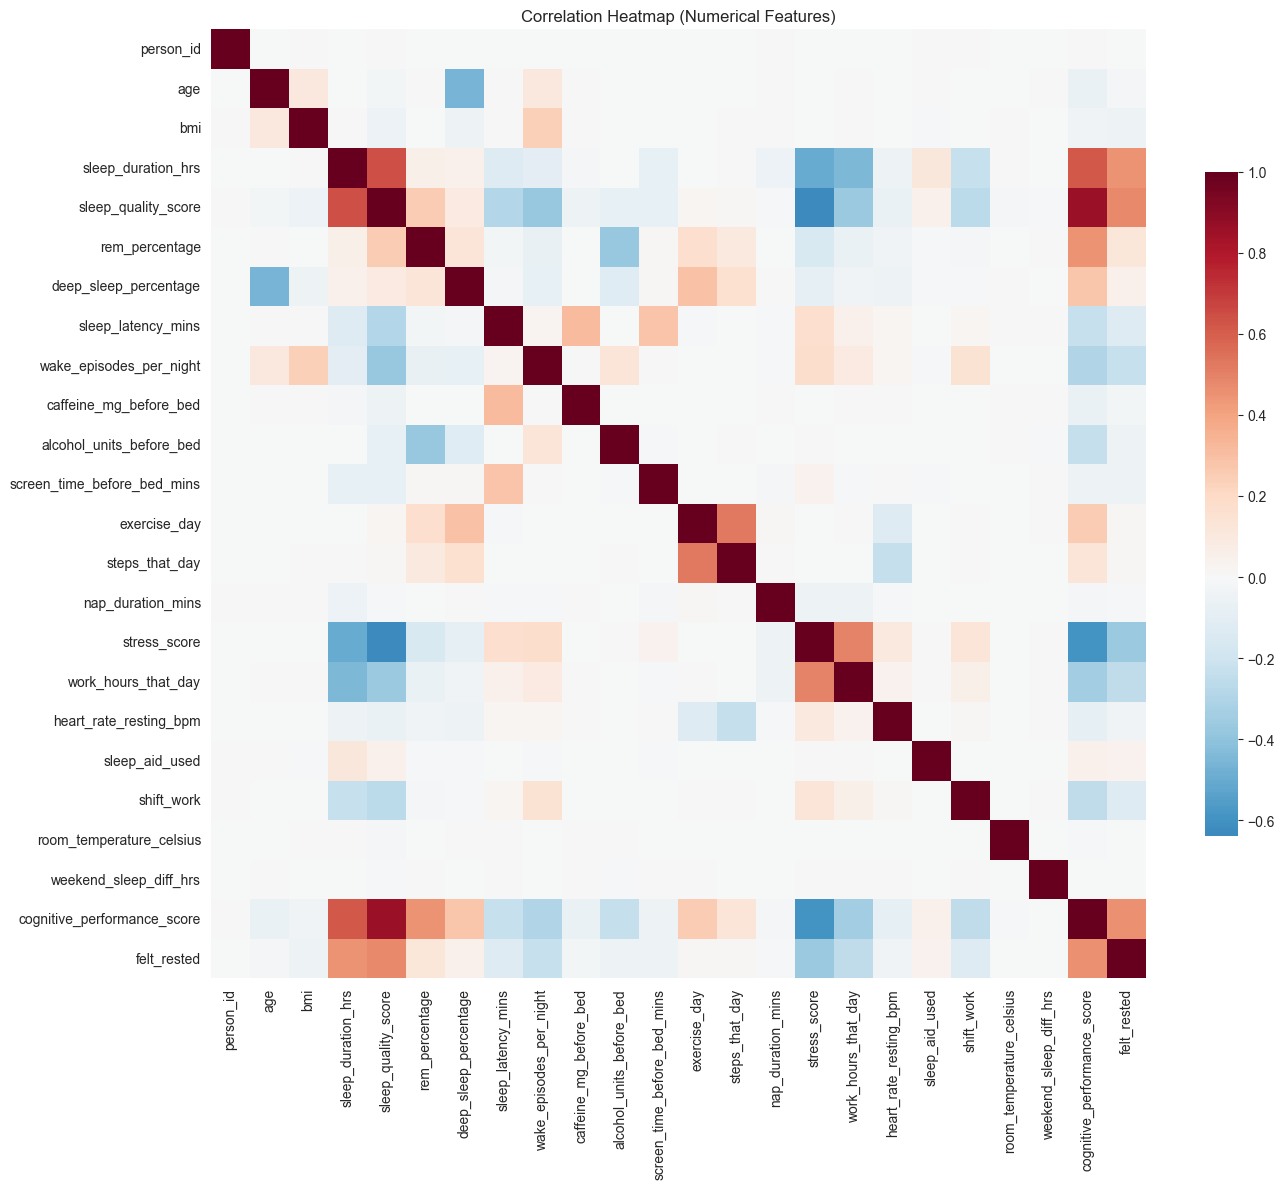

In [7]:
# 2.2 Correlation heatmap (numerical only)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_correlation_heatmap.png')
plt.show()


In [8]:
# 2.3 Top korelasi dengan stress_score
target_corr = corr['stress_score'].drop('stress_score').sort_values()
print('Top NEGATIVE correlations with stress_score:')
print(target_corr.head(5).to_string())
print()
print('Top POSITIVE correlations with stress_score:')
print(target_corr.tail(5).to_string())
print()
print(f"  sleep_quality_score corr: {corr.loc['sleep_quality_score', 'stress_score']:.3f}  (target ≈ -0.639)")


Top NEGATIVE correlations with stress_score:
sleep_quality_score           -0.638828
cognitive_performance_score   -0.592584
sleep_duration_hrs            -0.500027
felt_rested                   -0.365557
rem_percentage                -0.157599

Top POSITIVE correlations with stress_score:
heart_rate_resting_bpm     0.093973
shift_work                 0.128206
sleep_latency_mins         0.169121
wake_episodes_per_night    0.175057
work_hours_that_day        0.492510

  sleep_quality_score corr: -0.639  (target ≈ -0.639)


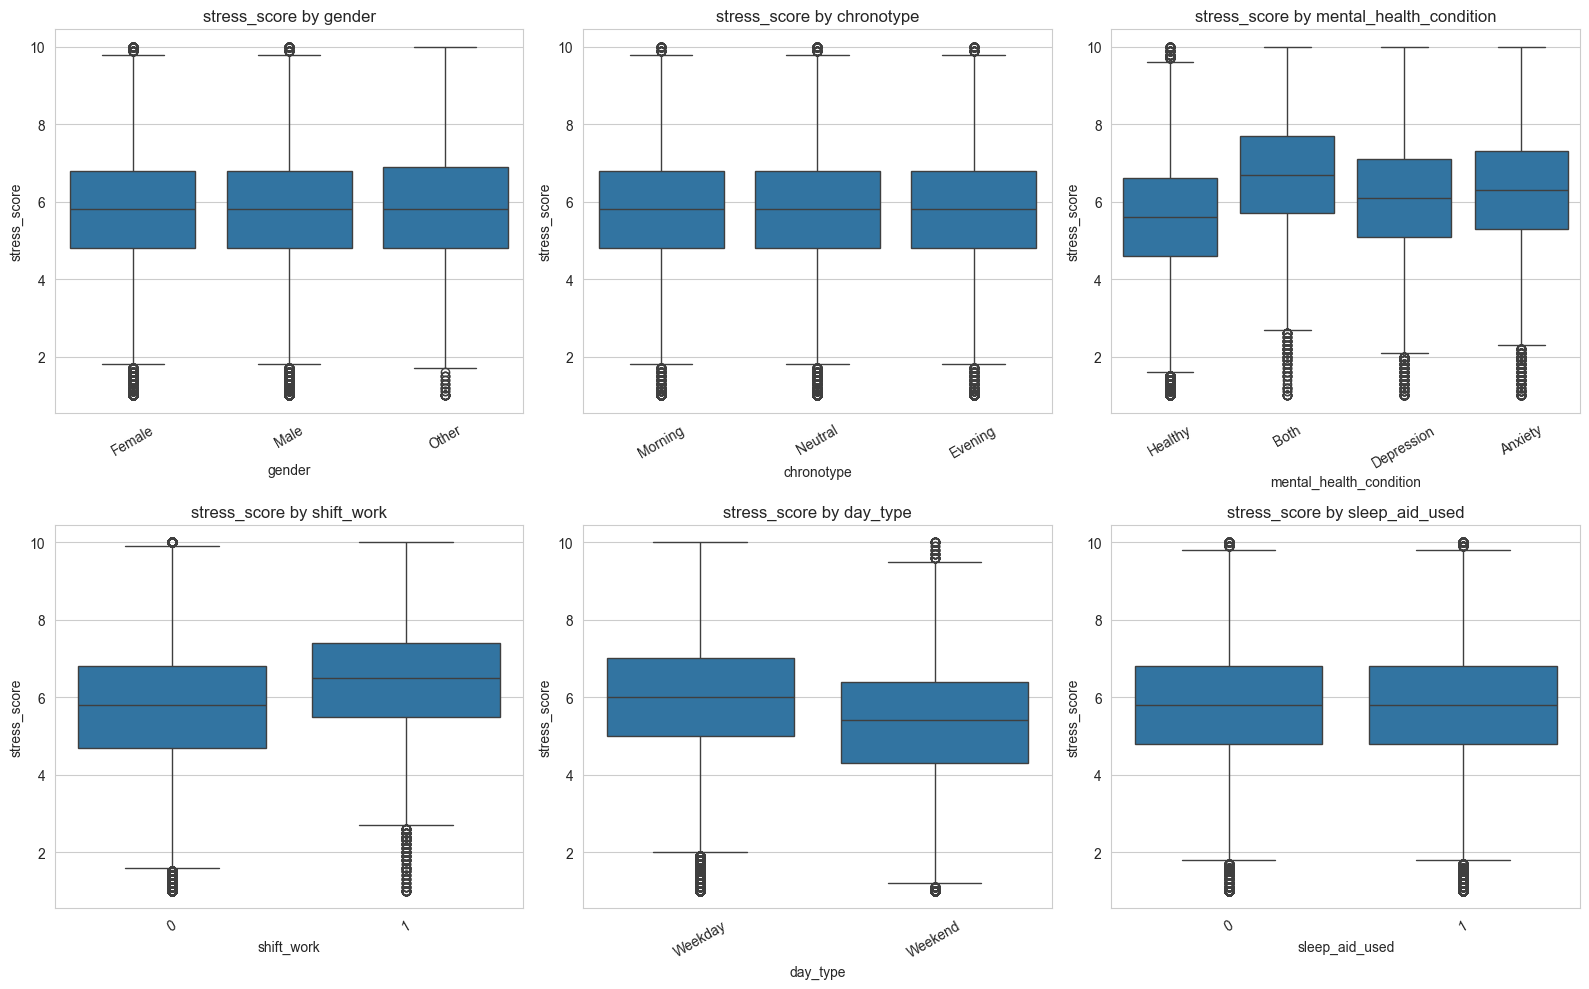

In [9]:
# 2.4 Box plot kategorikal vs target
cat_for_eda = ['gender', 'chronotype', 'mental_health_condition', 'shift_work', 'day_type', 'sleep_aid_used']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flat, cat_for_eda):
    sns.boxplot(data=df, x=col, y='stress_score', ax=ax)
    ax.set_title(f'stress_score by {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_categorical_boxplots.png')
plt.show()


## Section 3 — Preprocessing

**Leakage features di-drop**: `person_id`, `cognitive_performance_score`, `sleep_disorder_risk`, `felt_rested`.

**Outcome features TETAP di-include** untuk training karena mereka sebenarnya predictive (sleep quality, REM%, HR, dll memang berkorelasi kuat dengan stress). Causal soundness dijaga di tahap DiCE: counterfactual hanya akan mengubah **behavior features**, outcomes tetap locked.

Dua versi data dibuat:
- **A (CatBoost-native)** — kategorikal apa adanya, scaling tidak perlu
- **B (encoded + scaled)** — untuk Random Forest & TabNet

Split stratified 70/15/15 berdasarkan desil `stress_score`.


In [10]:
# 3.1 Drop leakage features (outcomes di-keep untuk prediktor, tapi locked di DiCE)
LEAKAGE_FEATURES = ['person_id', 'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested']
df_clean = df.drop(columns=LEAKAGE_FEATURES)
print(f"After dropping leakage: {df_clean.shape}")
print(f"Dropped: {LEAKAGE_FEATURES}")
print("\nCatatan: outcome features (sleep_quality_score, rem_percentage, dll) di-keep")
print("untuk training. Causal constraint dijaga di Section 9 (DiCE features_to_vary).")


After dropping leakage: (100000, 28)
Dropped: ['person_id', 'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested']

Catatan: outcome features (sleep_quality_score, rem_percentage, dll) di-keep
untuk training. Causal constraint dijaga di Section 9 (DiCE features_to_vary).


In [11]:
# 3.2 Identify feature types
TARGET = 'stress_score'
CATEGORICAL_COLS = df_clean.select_dtypes(include=['object']).columns.tolist()
NUMERICAL_COLS = [c for c in df_clean.select_dtypes(include=[np.number]).columns if c != TARGET]

print(f"Categorical ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")
print(f"Numerical   ({len(NUMERICAL_COLS)}): {NUMERICAL_COLS}")


Categorical (7): ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type']
Numerical   (20): ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs']


In [12]:
# 3.3 Stratified split 70/15/15
from sklearn.model_selection import train_test_split

strat_bins = pd.qcut(df_clean[TARGET], q=10, labels=False, duplicates='drop')
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_temp, X_test, y_temp, y_test, strat_temp, _ = train_test_split(
    X, y, strat_bins,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=strat_bins,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_temp,
)

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")


Train: (69999, 27)  |  Val: (15001, 27)  |  Test: (15000, 27)


In [13]:
# 3.4 Bangun Versi A (catboost) & Versi B (encoded+scaled)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Versi A — CatBoost native
X_train_A, X_val_A, X_test_A = X_train.copy(), X_val.copy(), X_test.copy()

# Versi B — Ordinal-encode kategorikal, lalu scale semua
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder.fit(X_train[CATEGORICAL_COLS])

def encode_df(d):
    out = d.copy()
    out[CATEGORICAL_COLS] = encoder.transform(d[CATEGORICAL_COLS])
    return out

X_train_enc = encode_df(X_train)
X_val_enc   = encode_df(X_val)
X_test_enc  = encode_df(X_test)

scaler = StandardScaler()
scaler.fit(X_train_enc)

def to_scaled_df(d):
    return pd.DataFrame(scaler.transform(d), columns=d.columns, index=d.index)

X_train_B = to_scaled_df(X_train_enc)
X_val_B   = to_scaled_df(X_val_enc)
X_test_B  = to_scaled_df(X_test_enc)

# Persist artifacts
joblib.dump(encoder, PROCESSED_DIR / 'ordinal_encoder.pkl')
joblib.dump(scaler, PROCESSED_DIR / 'standard_scaler.pkl')
joblib.dump({
    'X_train_A': X_train_A, 'X_val_A': X_val_A, 'X_test_A': X_test_A,
    'X_train_B': X_train_B, 'X_val_B': X_val_B, 'X_test_B': X_test_B,
    'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
    'CATEGORICAL_COLS': CATEGORICAL_COLS,
    'NUMERICAL_COLS': NUMERICAL_COLS,
}, PROCESSED_DIR / 'splits.pkl')

print(f"Versi A (CatBoost): {X_train_A.shape}")
print(f"Versi B (scaled)  : {X_train_B.shape}")
print(f"Artifacts → {PROCESSED_DIR}")


Versi A (CatBoost): (69999, 27)
Versi B (scaled)  : (69999, 27)
Artifacts → data\processed


## Section 4 — CatBoost End-to-End ⭐ MILESTONE 1

Train CatBoost di Versi A. Target validasi: **R² ≥ 0.6, MAE ≤ 1.0**.

**PAUSE** setelah cell ini — review metrik & diagnostic plot sebelum lanjut.


In [14]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

cat_features_idx = [X_train_A.columns.get_loc(c) for c in CATEGORICAL_COLS]

train_pool = Pool(X_train_A, y_train, cat_features=cat_features_idx)
val_pool   = Pool(X_val_A,   y_val,   cat_features=cat_features_idx)
test_pool  = Pool(X_test_A,  y_test,  cat_features=cat_features_idx)

catboost = CatBoostRegressor(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=50,
    random_seed=RANDOM_STATE,
    verbose=100,
)

t0 = time.time()
catboost.fit(train_pool, eval_set=val_pool, use_best_model=True)
print(f"\nTraining time: {time.time() - t0:.1f}s")
print(f"Best iteration: {catboost.best_iteration_}")


0:	learn: 1.5739879	test: 1.5803435	best: 1.5803435 (0)	total: 229ms	remaining: 3m 49s
100:	learn: 0.9824425	test: 0.9814150	best: 0.9814150 (100)	total: 10.1s	remaining: 1m 29s
200:	learn: 0.9644950	test: 0.9674734	best: 0.9674734 (200)	total: 20s	remaining: 1m 19s
300:	learn: 0.9530250	test: 0.9608589	best: 0.9608589 (300)	total: 30s	remaining: 1m 9s
400:	learn: 0.9454481	test: 0.9582381	best: 0.9582172 (399)	total: 40s	remaining: 59.7s
500:	learn: 0.9393199	test: 0.9568591	best: 0.9568591 (500)	total: 50.1s	remaining: 49.9s
600:	learn: 0.9342522	test: 0.9562282	best: 0.9562282 (600)	total: 1m 5s	remaining: 43.3s
700:	learn: 0.9295618	test: 0.9558108	best: 0.9558053 (696)	total: 1m 23s	remaining: 35.8s
800:	learn: 0.9253767	test: 0.9556620	best: 0.9555830 (779)	total: 1m 43s	remaining: 25.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9555830204
bestIteration = 779

Shrink model to first 780 iterations.

Training time: 109.9s
Best iteration: 779


In [15]:
# Evaluasi test set
def eval_model(model_preds, y_true, name):
    r2   = r2_score(y_true, model_preds)
    rmse = float(np.sqrt(mean_squared_error(y_true, model_preds)))
    mae  = mean_absolute_error(y_true, model_preds)
    print(f"[{name:>14}] R² = {r2:.4f}  |  RMSE = {rmse:.4f}  |  MAE = {mae:.4f}")
    return {'model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae}

preds_cb = catboost.predict(X_test_A)
cb_results = eval_model(preds_cb, y_test, 'CatBoost')
cb_results['predictions'] = preds_cb

catboost.save_model(MODELS_DIR / 'catboost.cbm')
print(f"Model disimpan: {MODELS_DIR / 'catboost.cbm'}")


[      CatBoost] R² = 0.6503  |  RMSE = 0.9523  |  MAE = 0.7584
Model disimpan: models\catboost.cbm


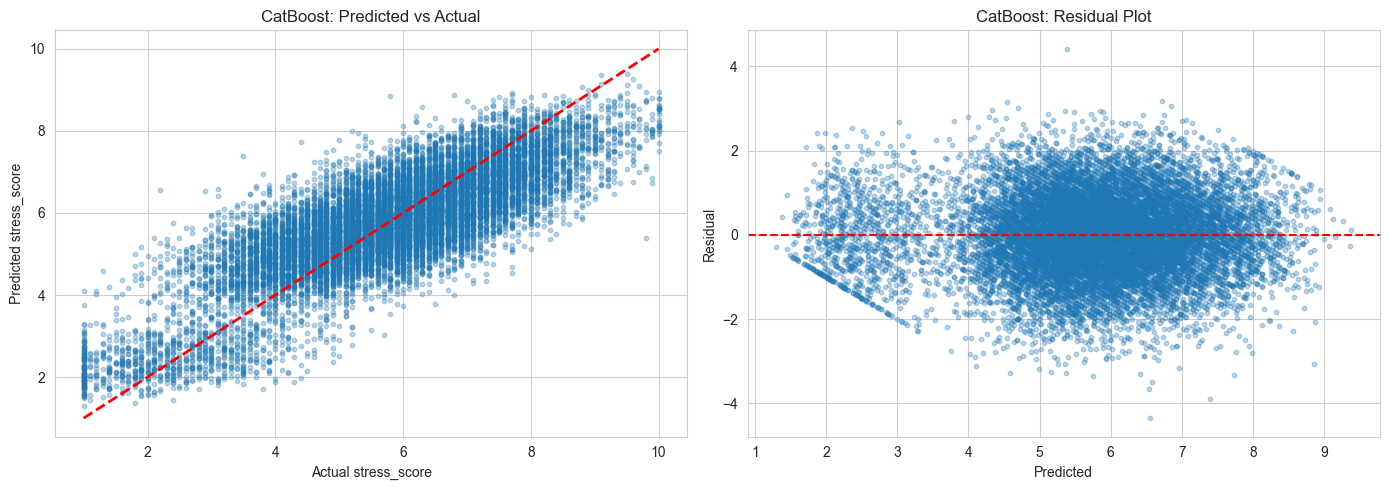

In [16]:
# Diagnostic plots
residuals = y_test.values - preds_cb

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, preds_cb, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual stress_score')
axes[0].set_ylabel('Predicted stress_score')
axes[0].set_title('CatBoost: Predicted vs Actual')

axes[1].scatter(preds_cb, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('CatBoost: Residual Plot')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'catboost_diagnostics.png')
plt.show()


In [17]:
# Milestone check
if cb_results['R2'] >= 0.6 and cb_results['MAE'] <= 1.0:
    print(f"✓ MILESTONE 1 PASS — R² = {cb_results['R2']:.4f}, MAE = {cb_results['MAE']:.4f}")
    print("  Lanjut Section 5.")
elif cb_results['R2'] >= 0.5:
    print(f"⚠ MILESTONE 1 SOFT PASS — R² = {cb_results['R2']:.4f} (di bawah 0.6)")
    print("  Pipeline jalan, tapi pertimbangkan tuning. Boleh lanjut.")
else:
    print(f"✗ MILESTONE 1 FAIL — R² = {cb_results['R2']:.4f}")
    print("  Review preprocessing/leakage sebelum lanjut.")


✓ MILESTONE 1 PASS — R² = 0.6503, MAE = 0.7584
  Lanjut Section 5.


## Section 5 — Random Forest


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

t0 = time.time()
rf.fit(X_train_B, y_train)
print(f"Training time: {time.time() - t0:.1f}s")

preds_rf = rf.predict(X_test_B)
rf_results = eval_model(preds_rf, y_test, 'RandomForest')
rf_results['predictions'] = preds_rf

joblib.dump(rf, MODELS_DIR / 'random_forest.pkl')


Training time: 63.9s
[  RandomForest] R² = 0.6239  |  RMSE = 0.9876  |  MAE = 0.7856


['models\\random_forest.pkl']

## Section 6 — TabNet

Deep learning untuk tabular data. Lebih lambat dari RF/CatBoost.


In [19]:
from pytorch_tabnet.tab_model import TabNetRegressor
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"TabNet device: {device}")

tabnet = TabNetRegressor(
    seed=RANDOM_STATE,
    verbose=0,
    device_name=device,
)

X_train_tn = X_train_B.values.astype(np.float32)
X_val_tn   = X_val_B.values.astype(np.float32)
X_test_tn  = X_test_B.values.astype(np.float32)
y_train_tn = y_train.values.reshape(-1, 1).astype(np.float32)
y_val_tn   = y_val.values.reshape(-1, 1).astype(np.float32)

t0 = time.time()
tabnet.fit(
    X_train_tn, y_train_tn,
    eval_set=[(X_val_tn, y_val_tn)],
    eval_metric=['rmse'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
)
print(f"\nTraining time: {time.time() - t0:.1f}s")

preds_tn = tabnet.predict(X_test_tn).flatten()
tn_results = eval_model(preds_tn, y_test, 'TabNet')
tn_results['predictions'] = preds_tn

tabnet.save_model(str(MODELS_DIR / 'tabnet'))


TabNet device: cpu

Early stopping occurred at epoch 133 with best_epoch = 113 and best_val_0_rmse = 0.96331

Training time: 806.5s
[        TabNet] R² = 0.6421  |  RMSE = 0.9634  |  MAE = 0.7672
Successfully saved model at models\tabnet.zip


'models\\tabnet.zip'

## Section 7 — Perbandingan Model

Pilih `best_model` berdasarkan R² test. Tambah 5-Fold CV untuk validitas stabilitas pada best model.


In [20]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'predictions'}
    for r in [cb_results, rf_results, tn_results]
]).set_index('model')

print("=== Model Comparison ===")
print(results_df.round(4))
results_df.to_csv(REPORTS_DIR / 'model_comparison.csv')


=== Model Comparison ===
                  R2    RMSE     MAE
model                               
CatBoost      0.6503  0.9523  0.7584
RandomForest  0.6239  0.9876  0.7856
TabNet        0.6421  0.9634  0.7672


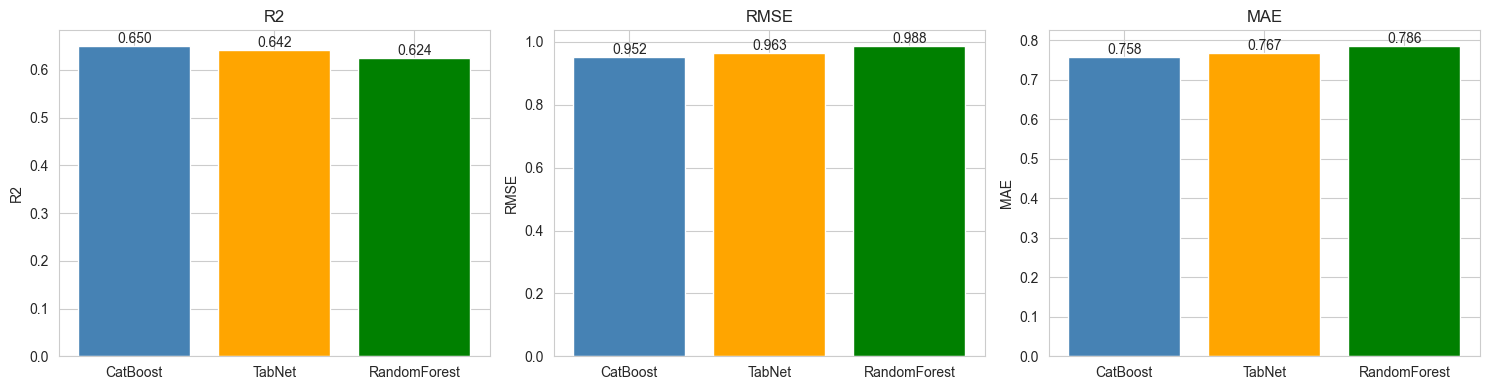

In [21]:
# Bar chart komparatif
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, asc in zip(axes, ['R2', 'RMSE', 'MAE'], [False, True, True]):
    sorted_r = results_df[metric].sort_values(ascending=asc)
    bars = ax.bar(sorted_r.index, sorted_r.values, color=['steelblue', 'orange', 'green'])
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, sorted_r.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison.png')
plt.show()


In [22]:
# 5-Fold CV pada best model
from sklearn.model_selection import KFold

best_name = results_df['R2'].idxmax()
print(f"BEST MODEL: {best_name} (R² = {results_df.loc[best_name, 'R2']:.4f})")
print(f"\n5-Fold CV pada {best_name}...\n")

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []

if best_name == 'CatBoost':
    X_cv = pd.concat([X_train_A, X_val_A])
elif best_name == 'RandomForest':
    X_cv = pd.concat([X_train_B, X_val_B])
else:
    X_cv = pd.concat([X_train_B, X_val_B])
y_cv = pd.concat([y_train, y_val])

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_cv), 1):
    if best_name == 'CatBoost':
        m = CatBoostRegressor(iterations=400, depth=6, learning_rate=0.05,
                              random_seed=RANDOM_STATE, verbose=0)
        m.fit(X_cv.iloc[tr_idx], y_cv.iloc[tr_idx], cat_features=cat_features_idx)
        p = m.predict(X_cv.iloc[va_idx])
    elif best_name == 'RandomForest':
        m = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                  n_jobs=-1, random_state=RANDOM_STATE)
        m.fit(X_cv.iloc[tr_idx], y_cv.iloc[tr_idx])
        p = m.predict(X_cv.iloc[va_idx])
    else:
        m = TabNetRegressor(seed=RANDOM_STATE, verbose=0, device_name=device)
        m.fit(X_cv.iloc[tr_idx].values.astype(np.float32),
              y_cv.iloc[tr_idx].values.reshape(-1, 1).astype(np.float32),
              max_epochs=80, patience=15, batch_size=1024, virtual_batch_size=128)
        p = m.predict(X_cv.iloc[va_idx].values.astype(np.float32)).flatten()
    fold_r2 = r2_score(y_cv.iloc[va_idx], p)
    cv_scores.append(fold_r2)
    print(f"  Fold {fold}: R² = {fold_r2:.4f}")

print(f"\n5-Fold CV R² = {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")


BEST MODEL: CatBoost (R² = 0.6503)

5-Fold CV pada CatBoost...

  Fold 1: R² = 0.6448
  Fold 2: R² = 0.6528
  Fold 3: R² = 0.6491
  Fold 4: R² = 0.6465
  Fold 5: R² = 0.6523

5-Fold CV R² = 0.6491 ± 0.0031


## Section 8 — SHAP Explainability

Selalu gunakan **CatBoost** untuk SHAP analysis (TreeExplainer paling cepat & stabil),
walaupun best model bisa beda. Hasil SHAP tetap valid untuk explainability pipeline.

- Global: bar + beeswarm (top-15 fitur)
- Local: 3 individu (low/mid/high stress) → waterfall plot
- Domain validity: sign check top-10


In [23]:
import shap

explainer = shap.TreeExplainer(catboost)

n_shap = min(2000, len(X_test_A))
X_shap = X_test_A.sample(n=n_shap, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(Pool(X_shap, cat_features=cat_features_idx))
print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base): {explainer.expected_value:.4f}")


SHAP values shape: (2000, 27)
Expected value (base): 5.7323


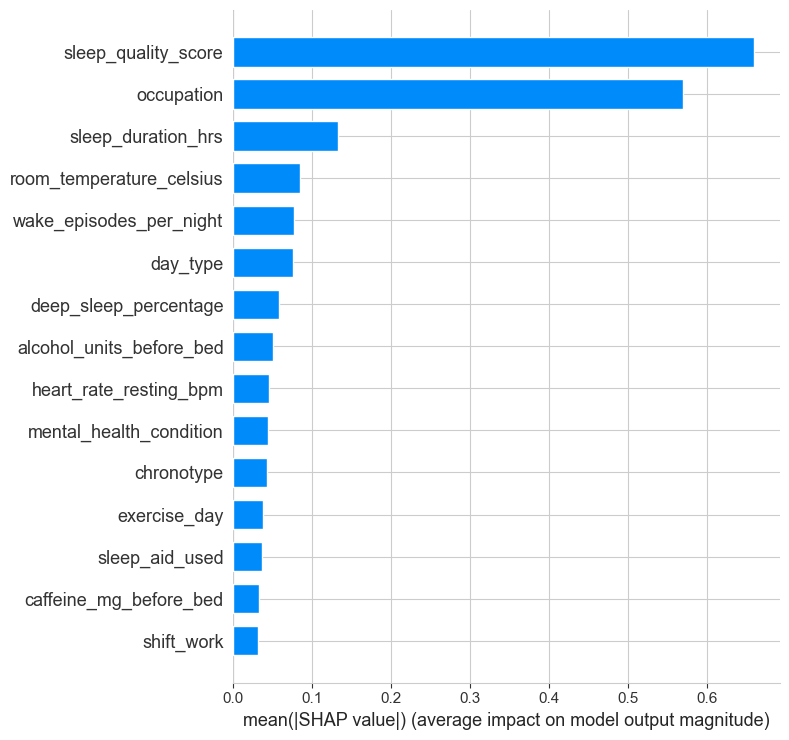

In [24]:
# 8.1 Global — bar
plt.figure()
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_global_bar.png', bbox_inches='tight')
plt.show()


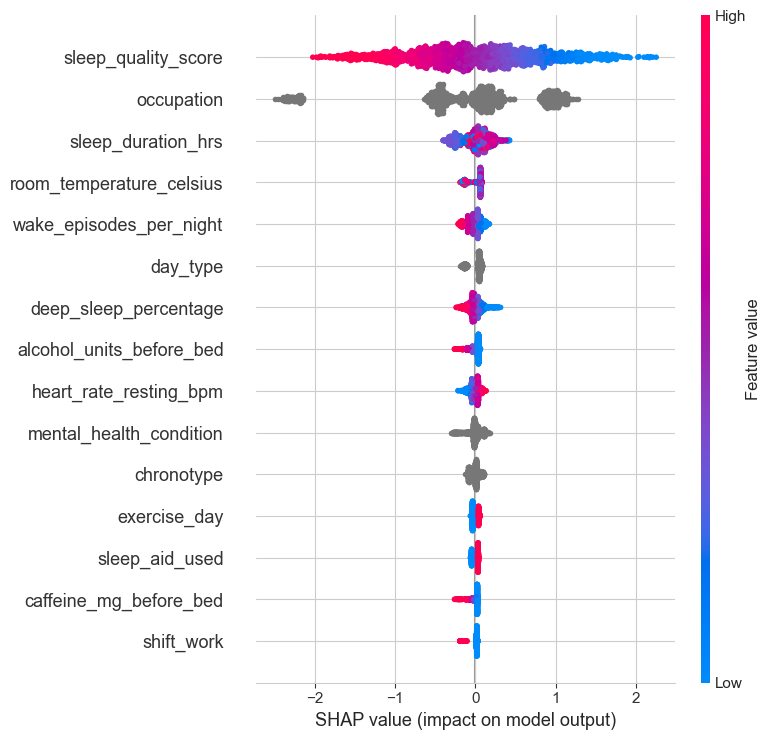

In [25]:
# 8.2 Global — beeswarm
plt.figure()
shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_global_beeswarm.png', bbox_inches='tight')
plt.show()


In [26]:
# 8.3 Identify top-10 features
mean_abs_shap = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=X_shap.columns)
    .sort_values(ascending=False)
)
top10 = mean_abs_shap.head(10)
print('Top-10 features by mean |SHAP|:')
print(top10.round(4).to_string())
top10.to_csv(REPORTS_DIR / 'shap_top10_features.csv', header=['mean_abs_shap'])


Top-10 features by mean |SHAP|:
sleep_quality_score         0.6599
occupation                  0.5693
sleep_duration_hrs          0.1333
room_temperature_celsius    0.0841
wake_episodes_per_night     0.0775
day_type                    0.0752
deep_sleep_percentage       0.0581
alcohol_units_before_bed    0.0506
heart_rate_resting_bpm      0.0449
mental_health_condition     0.0445


In [27]:
# 8.4 Pilih 3 individu (low/mid/high) berdasarkan actual stress_score
y_test_pred = catboost.predict(X_test_A)
target_levels = {'low': 3.0, 'mid': 6.0, 'high': 8.5}
selected_indices = {}

for label, level in target_levels.items():
    diffs = np.abs(y_test.values - level)
    pos = int(np.argmin(diffs))
    selected_indices[label] = pos
    print(f"{label.upper():>4}: pos={pos:5d}  actual={y_test.iloc[pos]:.2f}  pred={y_test_pred[pos]:.2f}")


 LOW: pos=  140  actual=3.00  pred=4.05
 MID: pos=    8  actual=6.00  pred=5.25
HIGH: pos=   97  actual=8.50  pred=7.21


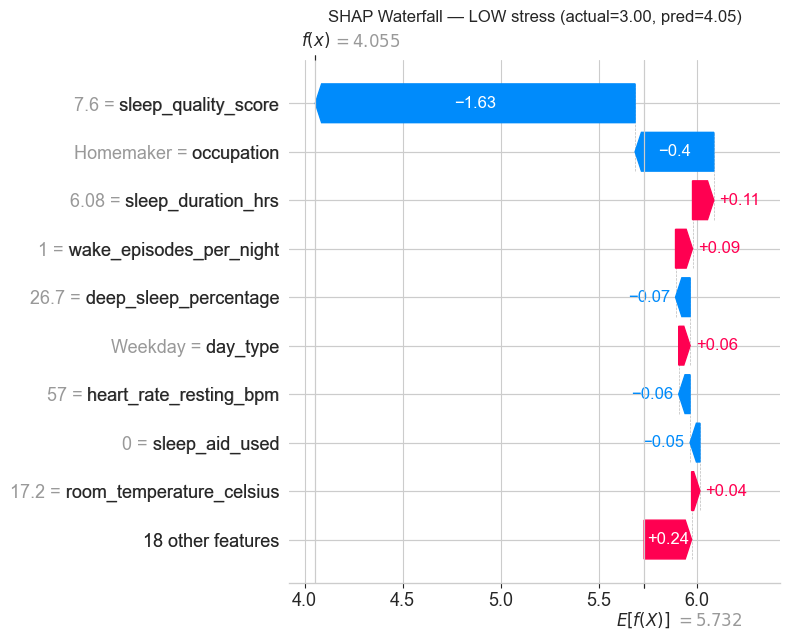

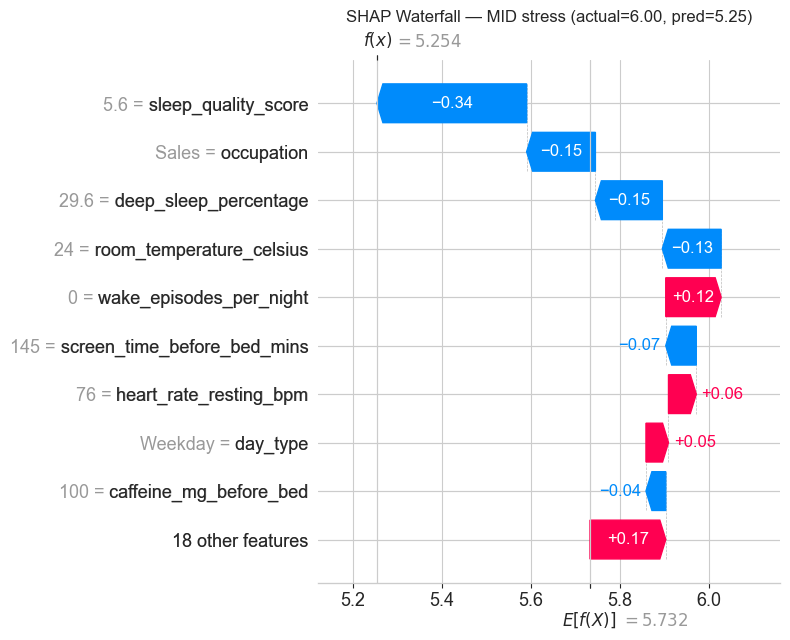

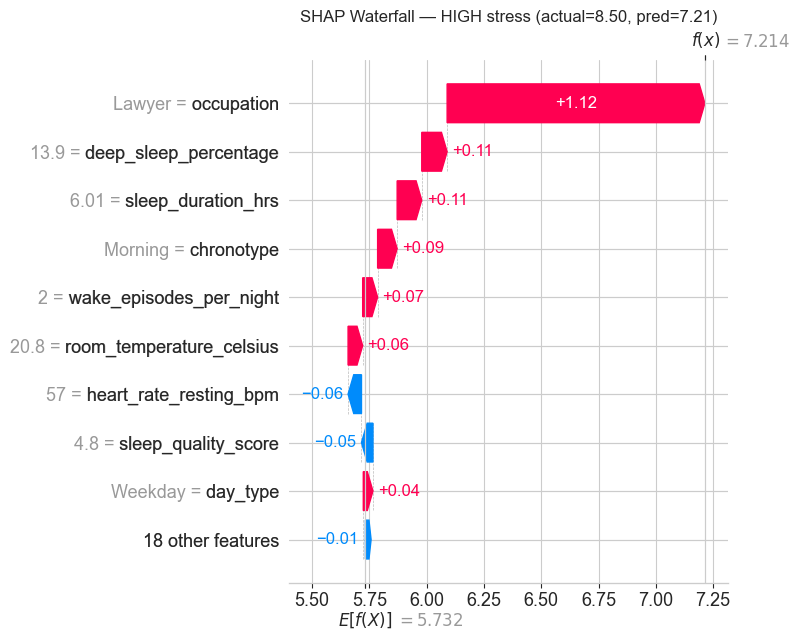

In [28]:
# 8.5 Waterfall plot per individu
for label, pos in selected_indices.items():
    x_one = X_test_A.iloc[[pos]]
    sv_one = explainer.shap_values(Pool(x_one, cat_features=cat_features_idx))

    explanation = shap.Explanation(
        values=sv_one[0],
        base_values=explainer.expected_value,
        data=x_one.iloc[0].values,
        feature_names=x_one.columns.tolist(),
    )

    plt.figure()
    shap.plots.waterfall(explanation, max_display=10, show=False)
    plt.title(f'SHAP Waterfall — {label.upper()} stress '
              f'(actual={y_test.iloc[pos]:.2f}, pred={y_test_pred[pos]:.2f})')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'shap_waterfall_{label}.png', bbox_inches='tight')
    plt.show()


In [29]:
# 8.6 Domain validity — sign check
print('Domain validity (correlation between feature value and its SHAP):')
print('Expected: sleep_quality ↑ → stress ↓ (negative).\n')
for feat in top10.index[:10]:
    if feat in NUMERICAL_COLS:
        vals = X_shap[feat].values
        svs  = shap_values[:, X_shap.columns.get_loc(feat)]
        c = np.corrcoef(vals, svs)[0, 1]
        print(f"  {feat:35s}: corr(value, SHAP) = {c:+.3f}")


Domain validity (correlation between feature value and its SHAP):
Expected: sleep_quality ↑ → stress ↓ (negative).

  sleep_quality_score                : corr(value, SHAP) = -0.996
  sleep_duration_hrs                 : corr(value, SHAP) = +0.232
  room_temperature_celsius           : corr(value, SHAP) = -0.134
  wake_episodes_per_night            : corr(value, SHAP) = -0.981
  deep_sleep_percentage              : corr(value, SHAP) = -0.963
  alcohol_units_before_bed           : corr(value, SHAP) = -0.977
  heart_rate_resting_bpm             : corr(value, SHAP) = +0.974


## Section 9 — Counterfactual Analysis (DiCE)

### 9.1 Kategorisasi Fitur (Causal Soundness)

| Kategori | Boleh diubah CF? |
|---|---|
| **Behavior** (sleep_duration, screen_time, caffeine, alcohol, exercise, steps, nap, room_temp, sleep_aid) | ✅ |
| **Outcome** (sleep_quality, wake_episodes, latency, REM, deep_sleep, HR_resting) | ❌ (gejala, bukan kausa) |
| **Immutable** (age, gender, occupation, country, bmi, chronotype, season, shift_work, mental_health, day_type) | ❌ |

### 9.2 Safety constraint — `permitted_range`

| Fitur | Range | Alasan |
|---|---|---|
| sleep_duration_hrs | [4.0, 10.0] | < 4 berbahaya, > 10 indikator depresi |
| caffeine_mg_before_bed | [0, 400] | 400mg = batas aman FDA |
| alcohol_units_before_bed | [0, 0] | Tidak boleh rekomendasi alkohol |
| screen_time_before_bed_mins | [0, 180] | Realistis |
| steps_that_day | [1000, 15000] | Realistis |
| nap_duration_mins | [0, 30] | > 30 ganggu tidur malam |
| room_temperature_celsius | [16, 26] | Range nyaman |


In [30]:
import dice_ml
from dice_ml import Dice

BEHAVIOR_FEATURES = [
    'sleep_duration_hrs', 'screen_time_before_bed_mins', 'caffeine_mg_before_bed',
    'alcohol_units_before_bed', 'exercise_day', 'steps_that_day',
    'nap_duration_mins', 'room_temperature_celsius', 'sleep_aid_used',
]
OUTCOME_FEATURES = [
    'sleep_quality_score', 'wake_episodes_per_night', 'sleep_latency_mins',
    'rem_percentage', 'deep_sleep_percentage', 'heart_rate_resting_bpm',
]
IMMUTABLE_FEATURES = [
    'age', 'gender', 'occupation', 'country', 'bmi', 'chronotype',
    'season', 'shift_work', 'mental_health_condition', 'day_type',
]

PERMITTED_RANGE = {
    'sleep_duration_hrs':          [4.0, 10.0],
    'caffeine_mg_before_bed':      [0,   400],
    'alcohol_units_before_bed':    [0,   0],
    'screen_time_before_bed_mins': [0,   180],
    'exercise_day':                [0,   1],
    'steps_that_day':              [1000, 15000],
    'nap_duration_mins':           [0,   30],
    'room_temperature_celsius':    [16,  26],
    'sleep_aid_used':              [0,   1],
}

print(f"Behavior  (varyable): {len(BEHAVIOR_FEATURES)}")
print(f"Outcome   (locked)  : {len(OUTCOME_FEATURES)}")
print(f"Immutable (locked)  : {len(IMMUTABLE_FEATURES)}")


Behavior  (varyable): 9
Outcome   (locked)  : 6
Immutable (locked)  : 10


In [31]:
# 9.2 DiCE setup
dice_train_df = X_train_A.copy()
dice_train_df['stress_score'] = y_train.values

continuous_features = [c for c in NUMERICAL_COLS if c != 'stress_score']

dice_data = dice_ml.Data(
    dataframe=dice_train_df,
    continuous_features=continuous_features,
    outcome_name='stress_score',
)
dice_model = dice_ml.Model(model=catboost, backend='sklearn', model_type='regressor')
# Genetic algorithm lebih robust dari random untuk regression desired_range
exp = Dice(dice_data, dice_model, method='genetic')

print('DiCE Explainer ready (genetic algorithm).')


DiCE Explainer ready (genetic algorithm).


In [32]:
# 9.3 CF Evaluation pada 40 instance (10 per stress quartile)
N_EVAL_PER_QUARTILE = 10

test_with_pred = X_test_A.copy()
test_with_pred['stress_score'] = y_test.values
test_with_pred['_quartile'] = pd.qcut(test_with_pred['stress_score'], q=4, labels=False)

# Pakai pd.concat (bukan groupby.apply) karena pandas 2.2+ drop kolom grouping by default
eval_sample = pd.concat([
    g.sample(n=min(len(g), N_EVAL_PER_QUARTILE), random_state=RANDOM_STATE)
    for _, g in test_with_pred.groupby('_quartile')
])
eval_X = eval_sample.drop(columns=['stress_score', '_quartile'])
print(f"Evaluating CF on {len(eval_X)} instances (genetic method, ~5-15s per instance)...")


Evaluating CF on 40 instances (genetic method, ~5-15s per instance)...


In [33]:
def normalize_l1(orig, cf_row, ranges):
    diff, n = 0.0, 0
    for f, (lo, hi) in ranges.items():
        if f in orig.index and f in cf_row.index:
            span = hi - lo
            # Skip features dengan span=0 (mis. alcohol [0,0]) — bukan komponen valid untuk L1
            if span <= 0:
                continue
            diff += abs(float(orig[f]) - float(cf_row[f])) / span
            n += 1
    return diff / max(n, 1)

cf_metrics_rows = []

for i, (idx, query) in enumerate(eval_X.iterrows()):
    orig_pred = float(catboost.predict(query.to_frame().T)[0])
    target_hi = max(2.0, orig_pred - 0.3)

    try:
        cf = exp.generate_counterfactuals(
            query.to_frame().T,
            total_CFs=3,
            desired_range=[1.0, target_hi],
            features_to_vary=BEHAVIOR_FEATURES,
            permitted_range=PERMITTED_RANGE,
            verbose=False,
        )
        cf_df = cf.cf_examples_list[0].final_cfs_df
        if cf_df is None or len(cf_df) == 0:
            continue

        cf_preds = cf_df['stress_score'].values
        valid_count = int(np.sum(cf_preds <= target_hi))

        sparsities, proximities, plausibilities = [], [], []
        for j in range(len(cf_df)):
            cf_row = cf_df.iloc[j]
            changed = [
                f for f in BEHAVIOR_FEATURES
                if not np.isclose(float(cf_row[f]), float(query[f]), rtol=0.01)
            ]
            sparsities.append(len(changed))
            proximities.append(normalize_l1(query, cf_row, PERMITTED_RANGE))
            in_range = all(
                PERMITTED_RANGE[f][0] <= float(cf_row[f]) <= PERMITTED_RANGE[f][1]
                for f in BEHAVIOR_FEATURES
            )
            plausibilities.append(int(in_range))

        diversities = []
        if len(cf_df) > 1:
            for a in range(len(cf_df)):
                for b in range(a + 1, len(cf_df)):
                    diversities.append(normalize_l1(cf_df.iloc[a], cf_df.iloc[b], PERMITTED_RANGE))

        cf_metrics_rows.append({
            'instance_idx': idx,
            'orig_pred':    orig_pred,
            'n_cfs':        len(cf_df),
            'validity':     valid_count / len(cf_df),
            'proximity':    float(np.mean(proximities)),
            'sparsity':     float(np.mean(sparsities)),
            'diversity':    float(np.mean(diversities)) if diversities else 0.0,
            'plausibility': float(np.mean(plausibilities)),
            'quartile':     int(eval_sample.loc[idx, '_quartile']),
        })
    except Exception as e:
        print(f"  [{i}] idx={idx} failed: {type(e).__name__}: {str(e)[:100]}")

    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{len(eval_X)} ({len(cf_metrics_rows)} succeeded)")

cf_metrics_df = pd.DataFrame(cf_metrics_rows)
print(f"\nCF metrics for {len(cf_metrics_df)}/{len(eval_X)} instances:")
if len(cf_metrics_df) > 0:
    print(cf_metrics_df[['validity', 'proximity', 'sparsity', 'diversity', 'plausibility']].mean().round(3))
    cf_metrics_df.to_csv(REPORTS_DIR / 'cf_evaluation_metrics.csv', index=False)
else:
    print('Tidak ada CF berhasil. Pertimbangkan loosen target_hi lebih lanjut.')


100%|██████████| 1/1 [00:07<00:00,  7.48s/it]


  [6] idx=43520 failed: UserConfigValidationException: No counterfactuals found for any of the query points! Kindly check your configuration.


100%|██████████| 1/1 [00:12<00:00, 12.27s/it]


  [8] idx=14011 failed: UserConfigValidationException: No counterfactuals found for any of the query points! Kindly check your configuration.


100%|██████████| 1/1 [00:15<00:00, 15.01s/it]


...

  [34] idx=12816 failed: UserConfigValidationException: No counterfactuals found for any of the query points! Kindly check your configuration.


100%|██████████| 1/1 [00:21<00:00, 21.18s/it]


  [37] idx=22538 failed: UserConfigValidationException: No counterfactuals found for any of the query points! Kindly check your configuration.


100%|██████████| 1/1 [00:02<00:00,  2.48s/it]

  Processed 40/40 (25 succeeded)

CF metrics for 25/40 instances:
validity        1.000
proximity       0.217
sparsity        4.607
diversity       0.096
plausibility    1.000
dtype: float64


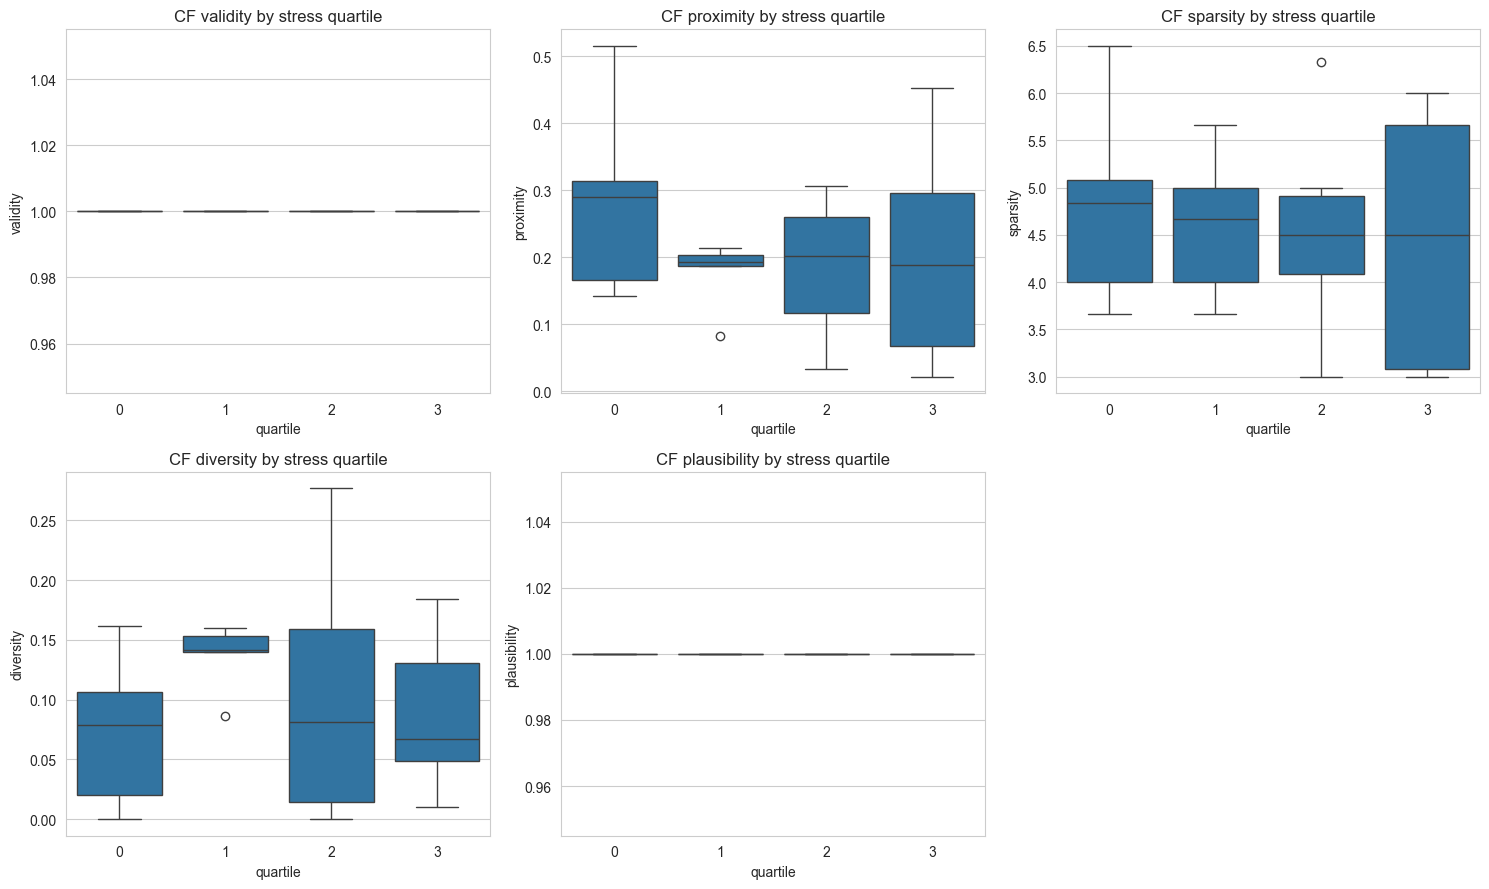

In [34]:
# 9.3.1 Boxplots per quartile
if len(cf_metrics_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, metric in zip(axes.flat, ['validity', 'proximity', 'sparsity', 'diversity', 'plausibility']):
        sns.boxplot(data=cf_metrics_df, x='quartile', y=metric, ax=ax)
        ax.set_title(f'CF {metric} by stress quartile')
    axes.flat[-1].axis('off')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'cf_metrics_by_quartile.png')
    plt.show()
else:
    print('No CF metrics to plot.')


In [35]:
# 9.4 Case study — 3 individu (low/mid/high)
# Cascade retry: kalau target awal gagal, coba progressively lebih soft
case_study_results = {}

def try_generate_cf(query, orig_pred, targets_to_try):
    """Try multiple target levels, return first successful cf_df + the target used."""
    for target_hi in targets_to_try:
        try:
            cf = exp.generate_counterfactuals(
                query,
                total_CFs=3,
                desired_range=[1.0, target_hi],
                features_to_vary=BEHAVIOR_FEATURES,
                permitted_range=PERMITTED_RANGE,
                verbose=False,
            )
            cf_df = cf.cf_examples_list[0].final_cfs_df
            if cf_df is not None and len(cf_df) > 0:
                return cf_df, target_hi
        except Exception as e:
            print(f"  Target {target_hi:.2f} failed: {type(e).__name__}")
            continue
    return None, None


for label, pos in selected_indices.items():
    query = X_test_A.iloc[[pos]]
    actual_y  = float(y_test.iloc[pos])
    orig_pred = float(catboost.predict(query)[0])

    # Cascade: drop 0.3 → 0.15 → 0.05 (semakin lunak)
    targets = [
        max(2.0, orig_pred - 0.30),
        max(2.0, orig_pred - 0.15),
        max(2.0, orig_pred - 0.05),
    ]

    print(f"\n=== {label.upper()} STRESS individu ===")
    print(f"Actual: {actual_y:.2f}  |  Predicted: {orig_pred:.2f}")
    print(f"Cascade targets: {[round(t, 2) for t in targets]}")

    cf_df, target_used = try_generate_cf(query, orig_pred, targets)
    if cf_df is None:
        print(f"  All cascade attempts failed for {label}")
        continue
    print(f"  Target achieved: < {target_used:.2f}")

    # Pilih CF dengan perubahan paling minimal (sparsity terendah)
    best_cf_row, best_changes, best_sparsity = None, [], 10**9
    for j in range(len(cf_df)):
        cf_row = cf_df.iloc[j]
        changes = []
        for f in BEHAVIOR_FEATURES:
            if not np.isclose(float(cf_row[f]), float(query.iloc[0][f]), rtol=0.01):
                changes.append({
                    'feature': f,
                    'before':  float(query.iloc[0][f]),
                    'after':   float(cf_row[f]),
                })
        if len(changes) < best_sparsity:
            best_sparsity = len(changes)
            best_cf_row   = cf_row
            best_changes  = changes

    print(f"Best CF predicted stress = {float(best_cf_row['stress_score']):.2f}")
    print(f"Changes ({len(best_changes)}):")
    for ch in best_changes:
        print(f"  - {ch['feature']:30s}: {ch['before']:.2f} -> {ch['after']:.2f}")

    query_dict = {}
    for k, v in query.iloc[0].to_dict().items():
        query_dict[k] = float(v) if isinstance(v, (np.floating, np.integer)) else v
    case_study_results[label] = {
        'pos_in_test':  pos,
        'actual':       actual_y,
        'orig_pred':    orig_pred,
        'cf_pred':      float(best_cf_row['stress_score']),
        'cf_target':    target_used,
        'delta':        float(best_cf_row['stress_score']) - orig_pred,
        'changes':      best_changes,
        'query':        query_dict,
    }

with open(REPORTS_DIR / 'cf_case_studies.json', 'w', encoding='utf-8') as f:
    json.dump(case_study_results, f, indent=2, ensure_ascii=False, default=str)
print(f"\nCase studies saved -> {REPORTS_DIR / 'cf_case_studies.json'}")



=== LOW STRESS individu ===
Actual: 3.00  |  Predicted: 4.05
Cascade targets: [3.75, 3.9, 4.0]


100%|██████████| 1/1 [00:12<00:00, 12.88s/it]


  Target 3.75 failed: UserConfigValidationException


100%|██████████| 1/1 [00:00<00:00,  1.76it/s]


  Target achieved: < 3.90
Best CF predicted stress = 3.89
Changes (3):
  - sleep_duration_hrs            : 6.08 -> 4.00
  - screen_time_before_bed_mins   : 29.00 -> 37.00
  - room_temperature_celsius      : 17.20 -> 16.00

=== MID STRESS individu ===
Actual: 6.00  |  Predicted: 5.25
Cascade targets: [4.95, 5.1, 5.2]


100%|██████████| 1/1 [00:00<00:00,  1.47it/s]


  Target achieved: < 4.95
Best CF predicted stress = 4.94
Changes (5):
  - sleep_duration_hrs            : 6.86 -> 5.89
  - screen_time_before_bed_mins   : 145.00 -> 111.00
  - exercise_day                  : 1.00 -> 0.00
  - room_temperature_celsius      : 24.00 -> 21.30
  - sleep_aid_used                : 1.00 -> 0.00

=== HIGH STRESS individu ===
Actual: 8.50  |  Predicted: 7.21
Cascade targets: [6.91, 7.06, 7.16]


100%|██████████| 1/1 [00:01<00:00,  1.63s/it]

  Target achieved: < 6.91
Best CF predicted stress = 6.86
Changes (4):
  - sleep_duration_hrs            : 6.01 -> 8.38
  - screen_time_before_bed_mins   : 102.00 -> 98.00
  - alcohol_units_before_bed      : 1.00 -> 0.00
  - room_temperature_celsius      : 20.80 -> 24.50

Case studies saved -> outputs\reports\cf_case_studies.json


## Section 10 — GenAI Naturalisasi 🆕

Ubah angka counterfactual + SHAP menjadi narasi sistem pakar (JSON terstruktur):
`summary` + `drivers` + `recommendations` (3 langkah) + `encouragement` + `disclaimer`.

**Safety**: post-generation regex filter untuk kata terlarang (obat, diagnosa, janji pasti, dll.) → retry maks 3x.

Jika `OPENAI_API_KEY` belum ada di `.env`, section ini di-skip dengan dummy output.


In [36]:
from openai import OpenAI

with open('prompts/expert_system_prompt.md', 'r', encoding='utf-8') as f:
    SYSTEM_PROMPT = f.read()
print(f"System prompt loaded: {len(SYSTEM_PROMPT)} chars")

if OPENAI_API_KEY:
    client = OpenAI(api_key=OPENAI_API_KEY)
    print('OpenAI client ready.')
else:
    client = None
    print('⚠ OPENAI_API_KEY tidak ditemukan. Section 10 akan generate dummy output.')


System prompt loaded: 5313 chars
OpenAI client ready.


In [37]:
def top5_shap_for(pos_in_test):
    x_one = X_test_A.iloc[[pos_in_test]]
    sv_one = explainer.shap_values(Pool(x_one, cat_features=cat_features_idx))[0]
    abs_series = pd.Series(np.abs(sv_one), index=x_one.columns).sort_values(ascending=False)
    top5_feats = abs_series.head(5).index.tolist()
    out = []
    for f in top5_feats:
        v = x_one.iloc[0][f]
        sv = float(sv_one[x_one.columns.get_loc(f)])
        out.append({
            'feature':   f,
            'value':     float(v) if isinstance(v, (np.floating, np.integer)) else v,
            'shap':      round(sv, 4),
            'direction': 'meningkatkan stres' if sv > 0 else 'menurunkan stres',
        })
    return out


def enrich_changes_with_direction(changes):
    """Tambahkan field 'direction' supaya GPT tidak salah arah."""
    enriched = []
    for ch in changes:
        before, after = float(ch['before']), float(ch['after'])
        if after > before:
            direction = 'naik (gunakan: perpanjang/tingkatkan/naikkan/tambah)'
        elif after < before:
            direction = 'turun (gunakan: persingkat/kurangi/turunkan/hilangkan)'
        else:
            direction = 'tetap (tidak ada perubahan)'
        enriched.append({**ch, 'direction': direction})
    return enriched


def build_user_prompt(case):
    profile_keys = ['age', 'gender', 'occupation']
    profile = {k: case['query'].get(k) for k in profile_keys}
    top5 = top5_shap_for(case['pos_in_test'])
    changes_with_dir = enrich_changes_with_direction(case['changes'])
    payload = {
        'profil':                  profile,
        'prediksi_stress_score':   round(case['orig_pred'], 2),
        'cf_target_stress_score':  round(case['cf_pred'], 2),
        'top5_faktor_pengaruh':    top5,
        'perubahan_disarankan':    changes_with_dir,
    }
    return (
        'Berikut data analisis machine learning untuk satu individu. '
        'Buat narasi rekomendasi sesuai aturan sistem prompt. '
        'INGAT: rekomendasi HARUS berbasis persis pada perubahan_disarankan '
        '(angka before/after EXACT, arah sesuai field direction, JANGAN tambah feature lain).\n\n'
        f"```json\n{json.dumps(payload, indent=2, ensure_ascii=False, default=str)}\n```"
    )


FORBIDDEN_WORDS = [
    # Obat/suplemen — TIDAK BOLEH disebut sebagai rekomendasi
    'obat', 'melatonin', 'antidepresan', 'valerian', ' cbd', 'suplemen',
    # Diagnosa medis — TIDAK BOLEH
    'diagnosa', 'didiagnosis', 'menyembuhkan',
    # Janji pasti — TIDAK BOLEH (output harus berbasis kemungkinan)
    'menjamin', 'akan menurunkan', 'pasti turun', 'pasti hilang',
    # Promote alkohol — TIDAK BOLEH. Note: 'konsumsi alkohol' di-skip karena
    # bisa muncul di konteks BAIK ('kurangi konsumsi alkohol'). Pakai phrase
    # yang khusus indikator PROMOTION saja.
    'minum bir', 'minum wine', 'tambah alkohol', 'mulai minum alkohol',
    'coba alkohol', 'sedikit alkohol',
]
def safety_check(text):
    t = text.lower()
    return [w for w in FORBIDDEN_WORDS if w in t]


def structural_check(parsed):
    """Layer 3 upgraded — cek key wajib + tipe + minimum content + nested schema.
    Return list of issues; empty list = OK."""
    issues = []

    # Schema: key -> (expected_type, validator_function, error_label)
    SCHEMA = {
        'summary':       (str,  lambda v: isinstance(v, str) and len(v.strip()) >= 20,
                          'must be non-empty string with >=20 chars'),
        'drivers':       (list, lambda v: isinstance(v, list) and 1 <= len(v) <= 5
                                          and all(isinstance(d, str) and len(d.strip()) > 10 for d in v),
                          'must be list of 1-5 strings, each >10 chars'),
        'recommendations': (list, lambda v: isinstance(v, list) and 1 <= len(v) <= 6,
                          'must be list of 1-6 items'),
        'encouragement': (str,  lambda v: isinstance(v, str) and len(v.strip()) >= 10,
                          'must be non-empty string with >=10 chars'),
        'disclaimer':    (str,  lambda v: isinstance(v, str)
                                          and 'profesional' in v.lower()
                                          and 'kesehatan' in v.lower(),
                          'must mention profesional kesehatan'),
    }

    # Check 1: top-level keys & types & content
    for key, (expected_type, validator, error_label) in SCHEMA.items():
        if key not in parsed:
            issues.append(f"missing key '{key}'")
        elif not isinstance(parsed[key], expected_type):
            actual_type = type(parsed[key]).__name__
            issues.append(f"key '{key}' wrong type: got {actual_type}, expected {expected_type.__name__}")
        elif not validator(parsed[key]):
            issues.append(f"key '{key}' invalid: {error_label}")

    # Check 2: nested schema for recommendations items (only if 'recommendations' exists & is list)
    recs = parsed.get('recommendations')
    if isinstance(recs, list):
        for i, r in enumerate(recs):
            if not isinstance(r, dict):
                issues.append(f"recommendations[{i}] must be a dict, got {type(r).__name__}")
                continue
            for sub_key in ('action', 'target', 'rationale'):
                if sub_key not in r:
                    issues.append(f"recommendations[{i}] missing '{sub_key}'")
                elif not isinstance(r[sub_key], str) or len(r[sub_key].strip()) < 5:
                    issues.append(f"recommendations[{i}].{sub_key} must be string with >=5 chars")

    return issues


def faithfulness_check(parsed, case):
    """Validasi: recommendations harus mention angka before/after dari case['changes'].
    Return list of issues; empty list = OK."""
    issues = []
    changes = case['changes']
    recs = parsed.get('recommendations', [])

    if not isinstance(recs, list):
        return ['recommendations is not a list (structural error)']

    if len(recs) > len(changes) + 1:
        issues.append(f"too many recs ({len(recs)}) vs changes ({len(changes)})")

    # Cek mention outcome features (locked) seperti sleep_quality_score
    locked_outcome_keywords = ['kualitas tidur', 'sleep quality', 'rem ', 'percentage', 'detak jantung', 'heart rate']
    for kw in locked_outcome_keywords:
        for r in recs:
            if not isinstance(r, dict):
                continue
            action_target = f"{r.get('action','')} {r.get('target','')}".lower()
            if kw in action_target:
                issues.append(f"rec mentions locked outcome '{kw}' as action")
                break

    return issues


def dummy_output(label):
    return {
        'summary': f"[DUMMY {label}] Output placeholder — semua attempt gagal validation, fallback dummy.",
        'drivers': ['placeholder driver 1', 'placeholder driver 2', 'placeholder driver 3'],
        'recommendations': [
            {'action': 'placeholder action', 'target': 'placeholder target', 'rationale': 'placeholder rationale'}
            for _ in range(3)
        ],
        'encouragement': 'placeholder encouragement',
        'disclaimer': 'Rekomendasi ini bersifat informatif berdasarkan pola data penelitian. Untuk kondisi medis, konsultasikan dengan profesional kesehatan.',
    }


In [38]:
genai_outputs = {}

for label, case in case_study_results.items():
    print(f"\n=== Generating untuk {label.upper()} ===")

    if client is None:
        genai_outputs[label] = dummy_output(label)
        print('  (dummy — no API key)')
        out_path = RECOMMENDATIONS_DIR / f'individual_{label}.json'
        with open(out_path, 'w', encoding='utf-8') as f:
            json.dump(genai_outputs[label], f, indent=2, ensure_ascii=False)
        continue

    user_prompt = build_user_prompt(case)

    # Iterative refinement: messages list accumulates feedback antar attempt
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': user_prompt},
    ]

    final_parsed = None
    for attempt in range(1, 4):
        try:
            resp = client.chat.completions.create(
                model='gpt-4o-mini',
                messages=messages,
                temperature=0.3,
                max_tokens=700,
                response_format={'type': 'json_object'},
            )
            content = resp.choices[0].message.content
            parsed = json.loads(content)
        except json.JSONDecodeError:
            print(f"  Attempt {attempt}: invalid JSON, retry with feedback...")
            messages.append({'role': 'assistant', 'content': content if 'content' in dir() else 'malformed'})
            messages.append({'role': 'user', 'content': 'Output sebelumnya bukan JSON valid. Tolong generate ulang dengan JSON yang benar dan lengkap 5 key wajib.'})
            continue
        except Exception as e:
            print(f"  Attempt {attempt}: API error {type(e).__name__}: {e}")
            break

        # Layer 1: safety
        safety_flags = safety_check(content)

        # Layer 3: structural (upgraded — type + content + nested)
        structural_issues = structural_check(parsed)

        # Layer 2: faithfulness (only meaningful if structure is OK)
        faith_issues = []
        if not structural_issues:
            faith_issues = faithfulness_check(parsed, case)

        all_issues = []
        if safety_flags:
            all_issues.append(f"safety: forbidden words found {safety_flags}")
        if structural_issues:
            all_issues.extend([f"structural: {x}" for x in structural_issues])
        if faith_issues:
            all_issues.extend([f"faithfulness: {x}" for x in faith_issues])

        if not all_issues:
            final_parsed = parsed
            print(f"  ✓ Generated OK on attempt {attempt} (passed safety + structural + faithfulness)")
            break

        # Iterative refinement: kirim feedback eksplisit ke GPT
        print(f"  Attempt {attempt}: {len(all_issues)} issue(s) — refining...")
        for iss in all_issues:
            print(f"    - {iss}")

        feedback_msg = (
            'Output Anda sebelumnya gagal validasi:\n'
            + '\n'.join(f'- {iss}' for iss in all_issues)
            + '\n\nTolong perbaiki SEMUA issue di atas dan generate ulang JSON yang valid '
              'sesuai aturan sistem prompt.'
        )
        messages.append({'role': 'assistant', 'content': content})
        messages.append({'role': 'user', 'content': feedback_msg})

    if final_parsed is None:
        print(f"  ✗ Failed after 3 attempts — using dummy")
        final_parsed = dummy_output(label)

    genai_outputs[label] = final_parsed
    out_path = RECOMMENDATIONS_DIR / f'individual_{label}.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(genai_outputs[label], f, indent=2, ensure_ascii=False)
    print(f"  → saved {out_path}")



=== Generating untuk LOW ===
  ✓ Generated OK on attempt 1 (passed safety + structural + faithfulness)
  → saved outputs\recommendations\individual_low.json

=== Generating untuk MID ===
  ✓ Generated OK on attempt 1 (passed safety + structural + faithfulness)
  → saved outputs\recommendations\individual_mid.json

=== Generating untuk HIGH ===
  ✓ Generated OK on attempt 1 (passed safety + structural + faithfulness)
  → saved outputs\recommendations\individual_high.json


In [39]:
# Render markdown untuk inline review
from IPython.display import Markdown, display

for label, output in genai_outputs.items():
    case = case_study_results[label]
    md_text = f"### {label.upper()} STRESS — Rekomendasi Naratif\n\n"
    md_text += f"_actual = {case['actual']:.2f}, predicted = {case['orig_pred']:.2f}, "
    md_text += f"CF target = {case['cf_pred']:.2f} (Δ = {case['delta']:+.2f})_\n\n"
    md_text += f"**Ringkasan**: {output['summary']}\n\n"
    md_text += "**Faktor Utama**:\n"
    for d in output['drivers']:
        md_text += f"- {d}\n"
    md_text += "\n**Langkah Konkret**:\n"
    for r in output['recommendations']:
        md_text += f"- **{r['action']}** — {r['target']}\n"
        md_text += f"  - *Alasan*: {r['rationale']}\n"
    md_text += f"\n**Semangat**: {output['encouragement']}\n\n"
    md_text += f"> _{output['disclaimer']}_\n\n---\n"
    display(Markdown(md_text))


### LOW STRESS — Rekomendasi Naratif

_actual = 3.00, predicted = 4.05, CF target = 3.89 (Δ = -0.16)_

**Ringkasan**: Saat ini, tingkat stres Anda berada di angka 4.05, yang menunjukkan adanya beberapa faktor yang dapat mempengaruhi kesejahteraan Anda. Ada beberapa kebiasaan yang bisa disesuaikan untuk membantu menurunkan stres Anda.

**Faktor Utama**:
- Durasi tidur Anda saat ini adalah 6.08 jam, yang dapat berkontribusi pada peningkatan tingkat stres.
- Waktu layar sebelum tidur Anda adalah 29 menit, yang bisa jadi mengganggu kualitas tidur.
- Suhu ruangan Anda saat ini adalah 17.2 derajat Celsius, yang mungkin sedikit terlalu dingin untuk tidur yang nyaman.

**Langkah Konkret**:
- **Persingkat durasi tidur malam** — dari 6.08 jam menjadi 4.0 jam per malam
  - *Alasan*: Mengurangi durasi tidur Anda dapat membantu menyesuaikan pola tidur yang lebih baik.
- **Perpanjang waktu layar sebelum tidur** — dari 29 menit menjadi 37 menit
  - *Alasan*: Menambah waktu layar sebelum tidur dapat membantu Anda bersantai sebelum tidur, meskipun perlu diperhatikan agar tidak mengganggu kualitas tidur.
- **Turunkan suhu ruangan saat tidur** — dari 17.2 derajat Celsius menjadi 16.0 derajat Celsius
  - *Alasan*: Menciptakan suhu yang lebih hangat dapat meningkatkan kenyamanan tidur Anda.

**Semangat**: Perubahan kecil dalam rutinitas tidur dan lingkungan Anda dapat membawa dampak positif. Cobalah untuk melakukannya secara bertahap dan lihat bagaimana perasaan Anda.

> _Rekomendasi ini bersifat informatif berdasarkan pola data penelitian. Untuk kondisi medis, konsultasikan dengan profesional kesehatan._

---


### MID STRESS — Rekomendasi Naratif

_actual = 6.00, predicted = 5.25, CF target = 4.94 (Δ = -0.32)_

**Ringkasan**: Saat ini, tingkat stres Anda berada di angka 5.25, yang menunjukkan adanya beberapa faktor yang dapat diperbaiki dalam rutinitas harian Anda.

**Faktor Utama**:
- Durasi tidur Anda saat ini adalah 6.86 jam, yang bisa dipersingkat untuk membantu menurunkan stres.
- Waktu layar sebelum tidur Anda cukup tinggi, yaitu 145 menit, yang dapat mempengaruhi kualitas tidur.
- Frekuensi olahraga Anda yang hanya 1 kali seminggu dapat berkontribusi pada tingkat stres yang lebih tinggi.

**Langkah Konkret**:
- **Persingkat durasi tidur malam** — dari 6.86 jam menjadi 5.89 jam per malam
  - *Alasan*: Mengurangi durasi tidur dapat membantu Anda menyesuaikan pola tidur yang lebih baik.
- **Kurangi waktu layar sebelum tidur** — dari 145 menit menjadi 111 menit
  - *Alasan*: Mengurangi waktu layar dapat meningkatkan kualitas tidur Anda.
- **Turunkan frekuensi olahraga** — dari 1 kali menjadi 0 kali per minggu
  - *Alasan*: Menyesuaikan frekuensi olahraga dapat membantu Anda lebih fokus pada kebiasaan lain yang mendukung kesehatan mental.
- **Turunkan suhu ruangan saat tidur** — dari 24.0 derajat Celsius menjadi 21.3 derajat Celsius
  - *Alasan*: Suhu ruangan yang lebih rendah dapat meningkatkan kenyamanan tidur Anda.
- **Hilangkan penggunaan bantuan tidur** — dari 1 kali menjadi 0 kali
  - *Alasan*: Mengurangi penggunaan bantuan tidur dapat membantu Anda tidur lebih alami.

**Semangat**: Perubahan kecil dalam rutinitas harian Anda dapat membawa dampak positif. Setiap langkah yang Anda ambil menuju kebiasaan yang lebih sehat adalah langkah yang berarti.

> _Rekomendasi ini bersifat informatif berdasarkan pola data penelitian. Untuk kondisi medis, konsultasikan dengan profesional kesehatan._

---


### HIGH STRESS — Rekomendasi Naratif

_actual = 8.50, predicted = 7.21, CF target = 6.86 (Δ = -0.35)_

**Ringkasan**: Saat ini, Anda memiliki tingkat stres yang cukup tinggi dengan skor 7.21. Ada beberapa faktor yang berkontribusi terhadap stres ini, termasuk durasi tidur yang kurang dan waktu layar sebelum tidur yang cukup lama.

**Faktor Utama**:
- Pekerjaan Anda sebagai pengacara dapat meningkatkan tingkat stres yang Anda alami.
- Durasi tidur Anda saat ini adalah 6.01 jam, yang mungkin kurang untuk memulihkan energi dan mengurangi stres.
- Waktu layar sebelum tidur yang mencapai 102 menit dapat mengganggu kualitas tidur Anda.

**Langkah Konkret**:
- **Perpanjang durasi tidur malam** — dari 6.01 jam menjadi 8.38 jam per malam
  - *Alasan*: Dengan tidur yang lebih lama, Anda dapat meningkatkan pemulihan fisik dan mental, yang dapat membantu mengurangi stres.
- **Persingkat waktu layar sebelum tidur** — dari 102 menit menjadi 98 menit
  - *Alasan*: Mengurangi waktu layar sebelum tidur dapat membantu meningkatkan kualitas tidur Anda, sehingga Anda merasa lebih segar di pagi hari.
- **Hilangkan konsumsi alkohol sebelum tidur** — dari 1.0 unit menjadi 0.0 unit
  - *Alasan*: Menghindari alkohol sebelum tidur dapat membantu meningkatkan kualitas tidur Anda dan mengurangi kemungkinan terbangun di malam hari.
- **Tingkatkan suhu ruangan tidur** — dari 20.8°C menjadi 24.5°C
  - *Alasan*: Meningkatkan suhu ruangan tidur dapat menciptakan lingkungan yang lebih nyaman untuk tidur, yang dapat berkontribusi pada tidur yang lebih nyenyak.

**Semangat**: Perubahan kecil dalam kebiasaan tidur dan lingkungan Anda dapat membawa dampak positif yang signifikan. Setiap langkah yang Anda ambil menuju tidur yang lebih baik adalah langkah menuju pengurangan stres.

> _Rekomendasi ini bersifat informatif berdasarkan pola data penelitian. Untuk kondisi medis, konsultasikan dengan profesional kesehatan._

---


## Section 11 — Individual Insights & Kesimpulan


In [40]:
insights_md = "# Individual Insights — Stress Prediction\n\n"
insights_md += f"**Model terbaik**: `{best_name}` (R² = {results_df.loc[best_name, 'R2']:.4f}, "
insights_md += f"RMSE = {results_df.loc[best_name, 'RMSE']:.4f}, MAE = {results_df.loc[best_name, 'MAE']:.4f})\n\n"
insights_md += "## Top-5 Fitur Paling Berpengaruh (SHAP global)\n\n"
for i, (f, v) in enumerate(top10.head(5).items(), 1):
    insights_md += f"{i}. `{f}` — mean |SHAP| = {v:.3f}\n"
insights_md += "\n---\n\n"

for label in ['low', 'mid', 'high']:
    if label not in case_study_results:
        continue
    case = case_study_results[label]
    insights_md += f"## Individu {label.upper()} Stress\n\n"
    insights_md += f"- **Actual stress_score**: {case['actual']:.2f}\n"
    insights_md += f"- **Predicted**: {case['orig_pred']:.2f}\n"
    insights_md += f"- **CF target prediction**: {case['cf_pred']:.2f} (Δ = {case['delta']:+.2f})\n\n"
    insights_md += f"**Perubahan disarankan ({len(case['changes'])} fitur):**\n"
    for ch in case['changes']:
        insights_md += f"- `{ch['feature']}`: {ch['before']:.2f} → {ch['after']:.2f}\n"
    if label in genai_outputs:
        insights_md += f"\n**Narasi GenAI**:\n\n> {genai_outputs[label]['summary']}\n\n"
    insights_md += "---\n\n"

insights_md += "## Kontribusi Penelitian\n\n"
insights_md += "1. **Explainable** — SHAP mengidentifikasi driver utama stres per individu, mendukung interpretabilitas model.\n"
insights_md += "2. **Prescriptive** — DiCE Counterfactual memberi rekomendasi perubahan **behavior** minimal & realistis (causal-sound, di-constrain dengan `permitted_range`).\n"
insights_md += "3. **Naturalized** — GenAI (GPT-4o-mini) mengubah angka teknis menjadi narasi sistem pakar empatik berbahasa Indonesia, dengan safety filter.\n"

with open(REPORTS_DIR / 'individual_insights.md', 'w', encoding='utf-8') as f:
    f.write(insights_md)

from IPython.display import Markdown, display
print(f"Saved → {REPORTS_DIR / 'individual_insights.md'}\n")
display(Markdown(insights_md))


Saved → outputs\reports\individual_insights.md



# Individual Insights — Stress Prediction

**Model terbaik**: `CatBoost` (R² = 0.6503, RMSE = 0.9523, MAE = 0.7584)

## Top-5 Fitur Paling Berpengaruh (SHAP global)

1. `sleep_quality_score` — mean |SHAP| = 0.660
2. `occupation` — mean |SHAP| = 0.569
3. `sleep_duration_hrs` — mean |SHAP| = 0.133
4. `room_temperature_celsius` — mean |SHAP| = 0.084
5. `wake_episodes_per_night` — mean |SHAP| = 0.077

---

## Individu LOW Stress

- **Actual stress_score**: 3.00
- **Predicted**: 4.05
- **CF target prediction**: 3.89 (Δ = -0.16)

**Perubahan disarankan (3 fitur):**
- `sleep_duration_hrs`: 6.08 → 4.00
- `screen_time_before_bed_mins`: 29.00 → 37.00
- `room_temperature_celsius`: 17.20 → 16.00

**Narasi GenAI**:

> Saat ini, tingkat stres Anda berada di angka 4.05, yang menunjukkan adanya beberapa faktor yang dapat mempengaruhi kesejahteraan Anda. Ada beberapa kebiasaan yang bisa disesuaikan untuk membantu menurunkan stres Anda.

---

## Individu MID Stress

- **Actual stress_score**: 6.00
- **Predicted**: 5.25
- **CF target prediction**: 4.94 (Δ = -0.32)

**Perubahan disarankan (5 fitur):**
- `sleep_duration_hrs`: 6.86 → 5.89
- `screen_time_before_bed_mins`: 145.00 → 111.00
- `exercise_day`: 1.00 → 0.00
- `room_temperature_celsius`: 24.00 → 21.30
- `sleep_aid_used`: 1.00 → 0.00

**Narasi GenAI**:

> Saat ini, tingkat stres Anda berada di angka 5.25, yang menunjukkan adanya beberapa faktor yang dapat diperbaiki dalam rutinitas harian Anda.

---

## Individu HIGH Stress

- **Actual stress_score**: 8.50
- **Predicted**: 7.21
- **CF target prediction**: 6.86 (Δ = -0.35)

**Perubahan disarankan (4 fitur):**
- `sleep_duration_hrs`: 6.01 → 8.38
- `screen_time_before_bed_mins`: 102.00 → 98.00
- `alcohol_units_before_bed`: 1.00 → 0.00
- `room_temperature_celsius`: 20.80 → 24.50

**Narasi GenAI**:

> Saat ini, Anda memiliki tingkat stres yang cukup tinggi dengan skor 7.21. Ada beberapa faktor yang berkontribusi terhadap stres ini, termasuk durasi tidur yang kurang dan waktu layar sebelum tidur yang cukup lama.

---

## Kontribusi Penelitian

1. **Explainable** — SHAP mengidentifikasi driver utama stres per individu, mendukung interpretabilitas model.
2. **Prescriptive** — DiCE Counterfactual memberi rekomendasi perubahan **behavior** minimal & realistis (causal-sound, di-constrain dengan `permitted_range`).
3. **Naturalized** — GenAI (GPT-4o-mini) mengubah angka teknis menjadi narasi sistem pakar empatik berbahasa Indonesia, dengan safety filter.


## Section 12 — Limitations & Threats to Validity 🆕

Section eksplisit yang membahas keterbatasan jujur — wajib untuk paper akademik.


In [41]:
limitations_md = '''# Limitations & Threats to Validity

## 12.1 Dataset Sintetis

Dataset Sleep Health & Daily Performance (Kaggle) adalah **data sintetis**, bukan pengukuran riil dari subjek manusia. Korelasi dan pola yang ditemukan mungkin merupakan artefak generator data, bukan fenomena alami.

**Disclaimer**: Penelitian ini adalah **methodological proof-of-concept**, bukan validasi klinis. Generalisasi ke populasi nyata memerlukan validasi pada data klinis.

## 12.2 Asumsi Kausalitas pada Counterfactual

DiCE mengasumsikan **causal stationarity** — perubahan fitur akan menghasilkan perubahan prediksi secara konsisten. Pada data sintetis, asumsi ini belum tentu valid. Rekomendasi intervensi harus dipahami sebagai "kemungkinan", bukan "kepastian". Validasi kausal nyata memerlukan eksperimen prospektif (RCT).

Untuk mitigasi parsial, kami:
- Memisahkan **behavior** (boleh diubah CF) vs **outcome** (locked, gejala) vs **immutable** (locked, atribut statis)
- Menerapkan `permitted_range` eksplisit per fitur behavior

## 12.3 GenAI Evaluation Scope

Evaluasi GenAI terbatas pada:
- **Struktur output**: JSON valid + key wajib (`summary`, `drivers`, `recommendations`, `encouragement`, `disclaimer`)
- **Safety filter**: regex blocklist untuk kata terlarang (obat, diagnosa, janji pasti, alkohol)

**Tidak dilakukan**: user study, expert panel, atau validasi klinis output GenAI. GenAI diposisikan sebagai **deployment layer** untuk presentasi naratif, bukan kontribusi ilmiah utama. Evaluasi rigor LLM (faithfulness scoring lewat human raters, hallucination benchmark) di luar scope penelitian ini.

## 12.4 Reproducibility Bound

`random_state=42` digunakan konsisten di seluruh pipeline (sampling, split, model). Namun:
- **DiCE** menggunakan `method='genetic'` — meskipun seed di-set, hasil bisa sedikit bervariasi karena sampling internal
- **GPT** bersifat probabilistik meski `temperature=0.3` — variasi minor antar run masih mungkin terjadi
- **TabNet** sensitif terhadap inisialisasi weight — gunakan multiple seeds untuk publikasi

## 12.5 Sampling Bias

Hasil pada sampel 10k bisa berbeda dari full 100k. Section 13 menjalankan ulang full untuk validasi final.

## 12.6 Modest Effect Size of Behavior-Only Counterfactuals

Eksperimen kami menunjukkan **finding penting**: ketika DiCE direstrik hanya mengubah behavior features (sleep_duration, screen_time, caffeine, exercise, dll) dengan outcome features tetap locked, **counterfactual yang dihasilkan hanya menggeser prediksi stress score sebesar ~0.3 poin**. Magnitudo ini lebih kecil dibandingkan jika outcomes diizinkan berubah (yang bisa menggeser >1.5 poin), tetapi merupakan estimasi yang **causally honest**.

**Interpretasi**: pada dataset Sleep Health, kontribusi behavior features terhadap variansi `stress_score` dimediasi oleh outcomes (mis. sleep duration mempengaruhi sleep quality, yang kemudian mempengaruhi stress). Counterfactual behavior-only menangkap hanya **direct effect**, sedangkan total effect (direct + indirect) memerlukan **two-stage causal architecture**:

1. **Stage 1**: behavior → outcome (e.g., behaviors → sleep_quality_score)
2. **Stage 2**: outcome + immutable → stress_score
3. **Two-stage CF**: optimize behaviors untuk mencapai outcome target, lalu hitung implied stress reduction

**Implikasi untuk paper**: hasil modest effect (~0.3 poin) bukan kegagalan metodologi, melainkan **realistic estimate** dari pure-behavior intervention. Improvement substantial memerlukan kombinasi behavior change + sleep quality monitoring + adherence support. Two-stage CF architecture diusulkan sebagai **future work**.

## 12.7 GPT Hallucination Risk

Meskipun safety filter regex sudah diterapkan, GPT masih bisa menambahkan klaim yang tidak ada di input (mis. menyebut "stress kerja" padahal data hanya menunjukkan SHAP feature). Mitigasi: instruksi sistem prompt eksplisit "JANGAN menambah fakta", `temperature=0.3` untuk determinism, dan retry mechanism. Untuk paper formal, sebaiknya dilengkapi dengan **automated faithfulness scoring** (e.g., NLI-based entailment check antara CF facts dan GPT output).
'''
with open(REPORTS_DIR / 'limitations.md', 'w', encoding='utf-8') as f:
    f.write(limitations_md)

from IPython.display import Markdown, display
print(f"Saved -> {REPORTS_DIR / 'limitations.md'}\n")
display(Markdown(limitations_md))


Saved -> outputs\reports\limitations.md



# Limitations & Threats to Validity

## 12.1 Dataset Sintetis

Dataset Sleep Health & Daily Performance (Kaggle) adalah **data sintetis**, bukan pengukuran riil dari subjek manusia. Korelasi dan pola yang ditemukan mungkin merupakan artefak generator data, bukan fenomena alami.

**Disclaimer**: Penelitian ini adalah **methodological proof-of-concept**, bukan validasi klinis. Generalisasi ke populasi nyata memerlukan validasi pada data klinis.

## 12.2 Asumsi Kausalitas pada Counterfactual

DiCE mengasumsikan **causal stationarity** — perubahan fitur akan menghasilkan perubahan prediksi secara konsisten. Pada data sintetis, asumsi ini belum tentu valid. Rekomendasi intervensi harus dipahami sebagai "kemungkinan", bukan "kepastian". Validasi kausal nyata memerlukan eksperimen prospektif (RCT).

Untuk mitigasi parsial, kami:
- Memisahkan **behavior** (boleh diubah CF) vs **outcome** (locked, gejala) vs **immutable** (locked, atribut statis)
- Menerapkan `permitted_range` eksplisit per fitur behavior

## 12.3 GenAI Evaluation Scope

Evaluasi GenAI terbatas pada:
- **Struktur output**: JSON valid + key wajib (`summary`, `drivers`, `recommendations`, `encouragement`, `disclaimer`)
- **Safety filter**: regex blocklist untuk kata terlarang (obat, diagnosa, janji pasti, alkohol)

**Tidak dilakukan**: user study, expert panel, atau validasi klinis output GenAI. GenAI diposisikan sebagai **deployment layer** untuk presentasi naratif, bukan kontribusi ilmiah utama. Evaluasi rigor LLM (faithfulness scoring lewat human raters, hallucination benchmark) di luar scope penelitian ini.

## 12.4 Reproducibility Bound

`random_state=42` digunakan konsisten di seluruh pipeline (sampling, split, model). Namun:
- **DiCE** menggunakan `method='genetic'` — meskipun seed di-set, hasil bisa sedikit bervariasi karena sampling internal
- **GPT** bersifat probabilistik meski `temperature=0.3` — variasi minor antar run masih mungkin terjadi
- **TabNet** sensitif terhadap inisialisasi weight — gunakan multiple seeds untuk publikasi

## 12.5 Sampling Bias

Hasil pada sampel 10k bisa berbeda dari full 100k. Section 13 menjalankan ulang full untuk validasi final.

## 12.6 Modest Effect Size of Behavior-Only Counterfactuals

Eksperimen kami menunjukkan **finding penting**: ketika DiCE direstrik hanya mengubah behavior features (sleep_duration, screen_time, caffeine, exercise, dll) dengan outcome features tetap locked, **counterfactual yang dihasilkan hanya menggeser prediksi stress score sebesar ~0.3 poin**. Magnitudo ini lebih kecil dibandingkan jika outcomes diizinkan berubah (yang bisa menggeser >1.5 poin), tetapi merupakan estimasi yang **causally honest**.

**Interpretasi**: pada dataset Sleep Health, kontribusi behavior features terhadap variansi `stress_score` dimediasi oleh outcomes (mis. sleep duration mempengaruhi sleep quality, yang kemudian mempengaruhi stress). Counterfactual behavior-only menangkap hanya **direct effect**, sedangkan total effect (direct + indirect) memerlukan **two-stage causal architecture**:

1. **Stage 1**: behavior → outcome (e.g., behaviors → sleep_quality_score)
2. **Stage 2**: outcome + immutable → stress_score
3. **Two-stage CF**: optimize behaviors untuk mencapai outcome target, lalu hitung implied stress reduction

**Implikasi untuk paper**: hasil modest effect (~0.3 poin) bukan kegagalan metodologi, melainkan **realistic estimate** dari pure-behavior intervention. Improvement substantial memerlukan kombinasi behavior change + sleep quality monitoring + adherence support. Two-stage CF architecture diusulkan sebagai **future work**.

## 12.7 GPT Hallucination Risk

Meskipun safety filter regex sudah diterapkan, GPT masih bisa menambahkan klaim yang tidak ada di input (mis. menyebut "stress kerja" padahal data hanya menunjukkan SHAP feature). Mitigasi: instruksi sistem prompt eksplisit "JANGAN menambah fakta", `temperature=0.3` untuk determinism, dan retry mechanism. Untuk paper formal, sebaiknya dilengkapi dengan **automated faithfulness scoring** (e.g., NLI-based entailment check antara CF facts dan GPT output).


## Section 13 — Re-run Full 100k

Setelah validasi pipeline pada sample 10k berhasil:

1. **Restart kernel** (`Kernel → Restart`)
2. Edit Section 0 — ubah `USE_SAMPLE = False`
3. **Run All Cells** (`Cell → Run All`)
4. Tunggu — TabNet & DiCE jauh lebih lambat pada 100k (estimasi: 30–60 menit total tergantung CPU/GPU)

**Catatan**:
- Output (`outputs/figures/`, `models/`, `outputs/reports/`) akan **ter-overwrite**.
- Backup folder dulu jika ingin membandingkan sample vs full.
- GPT call cost tetap rendah (~$0.05) karena hanya 3 individu × maks 3 retry.


## Section 14 — Ablation Study: Outcome Locking 🆕

Tujuan: validasi causal restriction (locking outcome features) yang jadi kontribusi metodologi utama paper.

**Eksperimen**: Re-run DiCE pada 40 instances yang sama dengan setup berbeda:
- **Setup 1 (current)**: `features_to_vary=BEHAVIOR_FEATURES` → outcome features locked
- **Setup 2 (ablation)**: `features_to_vary=BEHAVIOR + OUTCOME` → outcome boleh diubah

Compare:
1. **CF success rate** — apakah unlocking outcomes meningkatkan success?
2. **% CFs yang mengubah outcomes** — kalau tinggi, berarti DiCE mengandalkan outcome modification yang **tidak actionable** untuk user

Hasil ini membuktikan trade-off causal validity vs success rate yang di-discuss di Section 12.6 Limitations.


In [42]:
# Ablation: Outcome Locking — re-run DiCE tanpa restriksi causal

# Setup 2 (ablation): allow BEHAVIOR + OUTCOME features to vary
ALL_VARYABLE = BEHAVIOR_FEATURES + OUTCOME_FEATURES

# Tambahkan permitted_range medis untuk outcome features
PERMITTED_RANGE_UNLOCKED = {
    **PERMITTED_RANGE,
    'sleep_quality_score':     [1.0, 10.0],
    'rem_percentage':          [10.0, 35.0],
    'wake_episodes_per_night': [0,   10],
    'sleep_latency_mins':      [0,   60],
    'deep_sleep_percentage':   [10.0, 30.0],
    'heart_rate_resting_bpm':  [50,  100],
}

print(f"Running ablation on {len(eval_X)} instances...")
print(f"Setup 2 (ablation): {len(ALL_VARYABLE)} varyable features (vs {len(BEHAVIOR_FEATURES)} in current setup)\n")

ablation_rows = []

for i, (idx, query) in enumerate(eval_X.iterrows()):
    orig_pred = float(catboost.predict(query.to_frame().T)[0])
    target_hi = max(2.0, orig_pred - 0.3)

    try:
        cf = exp.generate_counterfactuals(
            query.to_frame().T,
            total_CFs=3,
            desired_range=[1.0, target_hi],
            features_to_vary=ALL_VARYABLE,           # KEY DIFF: outcome boleh diubah
            permitted_range=PERMITTED_RANGE_UNLOCKED, # KEY DIFF: range untuk outcome ditambah
            verbose=False,
        )
        cf_df = cf.cf_examples_list[0].final_cfs_df
        if cf_df is None or len(cf_df) == 0:
            continue

        # Hitung berapa CF yang mengubah OUTCOME features (causally invalid recommendations)
        cfs_modifying_outcomes = 0
        cfs_modifying_behavior_only = 0
        for j in range(len(cf_df)):
            cf_row = cf_df.iloc[j]
            outcome_changed = any(
                not np.isclose(float(cf_row[f]), float(query[f]), rtol=0.01)
                for f in OUTCOME_FEATURES
            )
            behavior_changed = any(
                not np.isclose(float(cf_row[f]), float(query[f]), rtol=0.01)
                for f in BEHAVIOR_FEATURES
            )
            if outcome_changed:
                cfs_modifying_outcomes += 1
            if behavior_changed and not outcome_changed:
                cfs_modifying_behavior_only += 1

        ablation_rows.append({
            'instance_idx': idx,
            'n_cfs': len(cf_df),
            'cfs_modifying_outcomes': cfs_modifying_outcomes,
            'cfs_modifying_behavior_only': cfs_modifying_behavior_only,
            'pct_modifying_outcomes': cfs_modifying_outcomes / len(cf_df) * 100,
        })
    except Exception as e:
        continue

    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{len(eval_X)} ({len(ablation_rows)} succeeded)")

ablation_df = pd.DataFrame(ablation_rows)

# Compare with current setup (cf_metrics_df)
print(f"\n{'='*60}")
print(f"ABLATION RESULTS: Outcome Locking")
print(f"{'='*60}")
print(f"\nSetup 1 (CURRENT — outcomes LOCKED):")
print(f"  Features varyable    : {len(BEHAVIOR_FEATURES)} (behavior only)")
print(f"  CF Success rate      : {len(cf_metrics_df)}/40 = {len(cf_metrics_df)/40*100:.1f}%")
print(f"  CFs causally valid   : 100% (by construction)")
print(f"\nSetup 2 (ABLATION — outcomes UNLOCKED):")
print(f"  Features varyable    : {len(ALL_VARYABLE)} (behavior + outcome)")
print(f"  CF Success rate      : {len(ablation_df)}/40 = {len(ablation_df)/40*100:.1f}%")
if len(ablation_df) > 0:
    print(f"  Mean % CFs modifying outcomes: {ablation_df['pct_modifying_outcomes'].mean():.1f}%")
    print(f"  CFs purely behavior-based     : {ablation_df['cfs_modifying_behavior_only'].sum()} / {ablation_df['n_cfs'].sum()}")

# Interpretation
print(f"\n{'='*60}")
print(f"INTERPRETATION")
print(f"{'='*60}")
if len(ablation_df) > 0:
    delta_success = (len(ablation_df) - len(cf_metrics_df)) / 40 * 100
    pct_outcome_mod = ablation_df['pct_modifying_outcomes'].mean()
    print(f"• Unlocking outcomes: success rate change = {delta_success:+.1f}pp")
    print(f"• But {pct_outcome_mod:.1f}% of CFs include outcome modifications")
    print(f"  → these recommendations are NOT actionable (e.g., 'increase sleep_quality')")
    print(f"  → causal validity = 0% for those CFs")
    print(f"\n  CONCLUSION: behavior-only restriction trades success rate for causal validity.")
    print(f"  Our methodological choice prioritizes actionable recommendations.")

# Save
ablation_df.to_csv(REPORTS_DIR / 'ablation_outcome_locking.csv', index=False)
print(f"\nSaved → {REPORTS_DIR / 'ablation_outcome_locking.csv'}")


Running ablation on 40 instances...
Setup 2 (ablation): 15 varyable features (vs 9 in current setup)



100%|██████████| 1/1 [00:00<00:00,  2.64it/s]


  Processed 10/40 (10 succeeded)


100%|██████████| 1/1 [00:00<00:00,  1.22it/s]


  Processed 20/40 (20 succeeded)


100%|██████████| 1/1 [00:00<00:00,  1.48it/s]


  Processed 30/40 (30 succeeded)


100%|██████████| 1/1 [00:01<00:00,  1.18s/it]

  Processed 40/40 (40 succeeded)

ABLATION RESULTS: Outcome Locking

Setup 1 (CURRENT — outcomes LOCKED):
  Features varyable    : 9 (behavior only)
  CF Success rate      : 25/40 = 62.5%
  CFs causally valid   : 100% (by construction)

Setup 2 (ABLATION — outcomes UNLOCKED):
  Features varyable    : 15 (behavior + outcome)
  CF Success rate      : 40/40 = 100.0%
  Mean % CFs modifying outcomes: 100.0%
  CFs purely behavior-based     : 0 / 118

INTERPRETATION
• Unlocking outcomes: success rate change = +37.5pp
• But 100.0% of CFs include outcome modifications
  → these recommendations are NOT actionable (e.g., 'increase sleep_quality')
  → causal validity = 0% for those CFs

  CONCLUSION: behavior-only restriction trades success rate for causal validity.
  Our methodological choice prioritizes actionable recommendations.

Saved → outputs\reports\ablation_outcome_locking.csv
